<a href="https://colab.research.google.com/github/lzhkaya98/Global_SSM_Variation/blob/main/Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#!pip install rasterio
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import numpy as np
import xarray as xr
import rasterio
from tqdm import tqdm
import pandas as pd

# 1. 设置输入输出路径
input_dir = "/content/drive/My Drive/Science/landcover"  # 替换为实际路径
output_nc = "/content/drive/My Drive/Science/landcover_2001-2024_yearly.nc"

# 2. 获取所有GeoTIFF文件并按时间排序
tiff_files = sorted(glob.glob(os.path.join(input_dir, "*.tif")))
print(f"找到 {len(tiff_files)} 个GeoTIFF文件")

# 4. 读取第一个文件获取空间尺寸
with rasterio.open(tiff_files[0]) as src:
    height, width = src.shape
    print(f"图像尺寸: {height}行 × {width}列")

# 5. 初始化三维数组 (时间, 高度, 宽度)
num_files = len(tiff_files)
variable_data = np.empty((num_files, height, width), dtype=np.float32)

# 6. 读取所有文件数据到数组
print("正在读取GeoTIFF文件...")
for i, file_path in enumerate(tqdm(tiff_files)):
    with rasterio.open(file_path) as src:
        # 读取第一个波段（假设土壤湿度数据在第一个波段）
        variable_data[i] = src.read(1)

        # 处理NoData值（根据实际数据调整）
        if src.nodata is not None:
            variable_data[i][variable_data[i] == src.nodata] = np.nan

# 7. 创建xarray Dataset
ds = xr.Dataset(
    data_vars={
        "landcover": (["time", "y", "x"], variable_data)
    }
)

# 8. 设置变量属性
#ds["soil_moisture"].attrs = {
#    "long_name": "Soil Moisture",
#    "units": "m³/m³",  # 根据实际数据调整
#    "description": "Monthly soil moisture derived from satellite observations"
#}

# 9. 设置全局属性
#ds.attrs = {
#    "title": "Global Monthly Soil Moisture (2000-2024)",
#    "source": "Satellite-derived product",
#    "history": f"Created on {pd.Timestamp.now().isoformat()}",
#    "spatial_dimensions": f"y: {height} pixels, x: {width} pixels"
#}

# 10. 保存为NetCDF文件
encoding = {
    "landcover": {
        "zlib": True,
        "complevel": 5,  # 压缩级别
        "dtype": "float32"
    }
}

ds.to_netcdf(output_nc, encoding=encoding)
print(f"成功创建NetCDF文件: {output_nc}")
print(f"文件维度: time={num_files}, y={height}, x={width}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
找到 24 个GeoTIFF文件
图像尺寸: 564行 × 1440列
正在读取GeoTIFF文件...


100%|██████████| 24/24 [00:06<00:00,  3.85it/s]


成功创建NetCDF文件: /content/drive/My Drive/Nature/landcover_2001-2024_yearly.nc
文件维度: time=24, y=564, x=1440


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


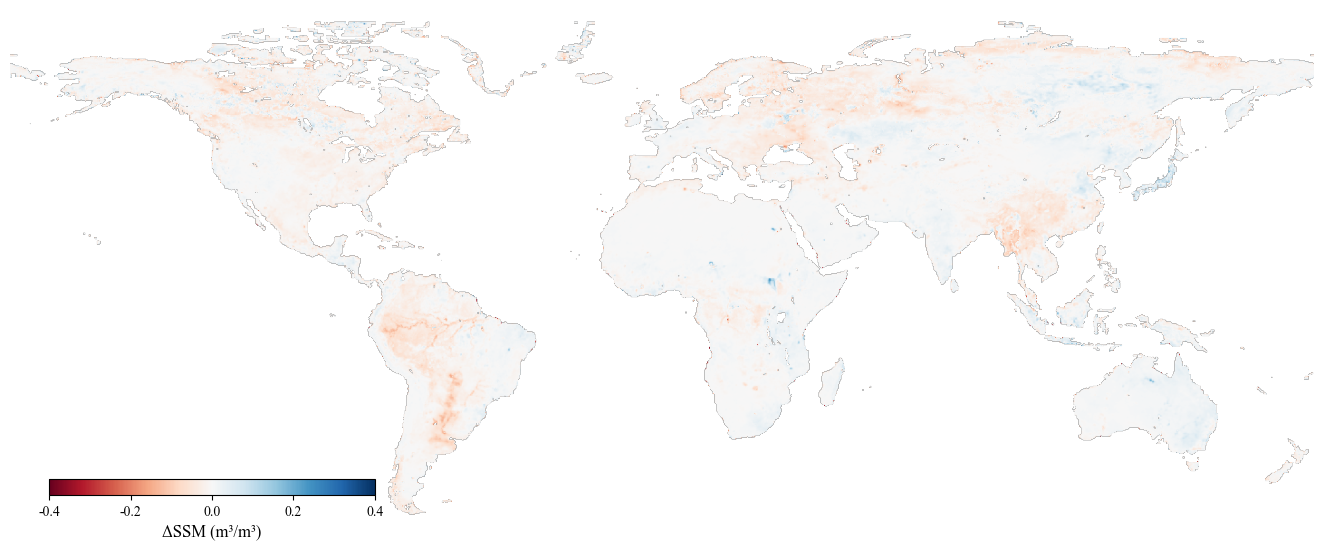

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 10  # Nature 喜欢清晰、可读的大小。

# 读取NC文件
ds = xr.open_dataset('/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc')
soil_moisture = ds['soil_moisture']

# 划分时间段（基于时间索引）
period1 = soil_moisture.isel(time=slice(0, 264))  # 2000-2021年（264个月）
period2 = soil_moisture.isel(time=slice(264, 300))  # 2022-2024年（36个月）

# 计算各时段平均值
mean_2000_2021 = period1.mean(dim='time')
mean_2022_2024 = period2.mean(dim='time')

# 计算差值（后期减前期）
difference = mean_2022_2024 - mean_2000_2021

# 字体美化设置
plt.rcParams['font.serif'] = "Times New Roman"
plt.rcParams['font.family'] = "serif"
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# 绘图
fig, ax = plt.subplots(figsize=(14.4, 5.64))

im = ax.imshow(difference, cmap='RdBu', vmin=-0.4, vmax=0.4)
ax.axis('off')  # 关闭主图的所有坐标轴和边框

# 7. 在左下角添加缩小的 Colorbar
# inset_axes 参数格式为：[x0, y0, width, height] (数值为主图宽高的比例)
# [0.03, 0.05, ... ] 表示距离左侧 3%，距离底部 5%
# [..., ..., 0.25, 0.03] 表示宽度占主图 25%，高度占主图 3%
cax = ax.inset_axes([0.03, 0.05, 0.25, 0.03])

# 将 colorbar 绑定到悬浮坐标轴 cax，并设置为水平方向
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')

# 设置标签和刻度
cbar.set_label('ΔSSM (m³/m³)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('2000-2021vs2022-2024_sm.png', dpi=300, bbox_inches='tight')
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


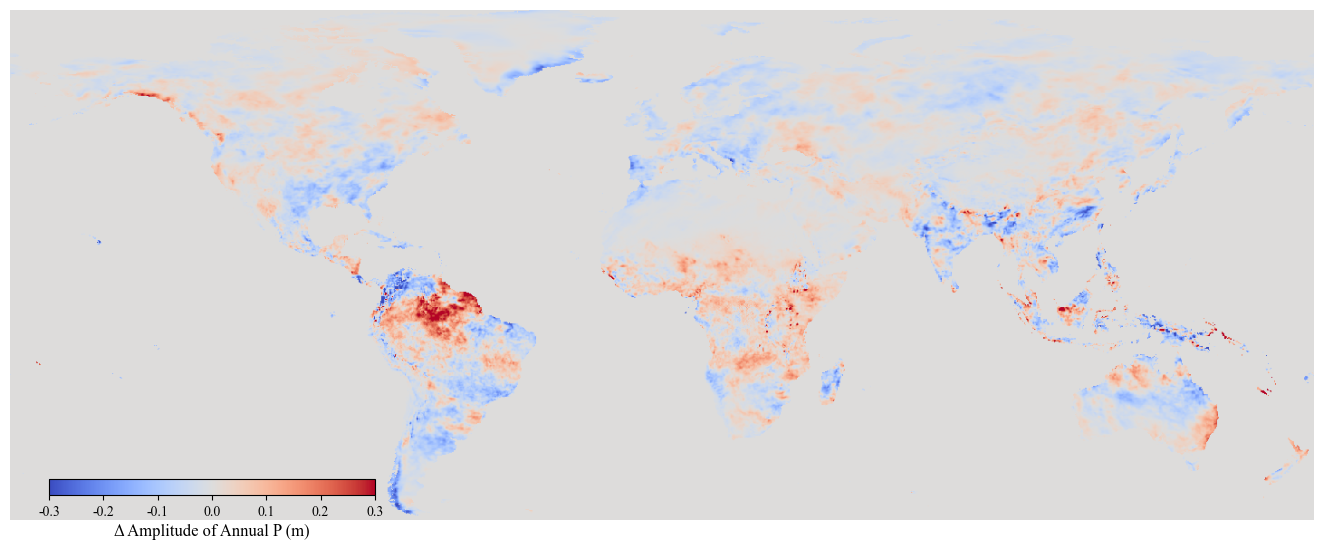

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 读取NC文件
ds = xr.open_dataset('/content/drive/My Drive/Science/P_2000-2024_monthly.nc')  #读取降水数据
P = ds['P']
real_times = pd.date_range(start='2000-01-01', periods=300, freq='MS')
P['time'] = real_times

# 2. 将月降水量转换为年降水总量
# 使用 groupby 按年分组，并对每个年份内的月份求和
annual_P = P.groupby('time.year').sum(dim='time')

# 3. 划分时间段
period1_annual = annual_P.sel(year=slice(2000, 2021))  # 2000-2021年
period2_annual = annual_P.sel(year=slice(2022, 2024))  # 2022-2024年

# 4. 计算年际变化幅度（标准差）

std_2000_2021 = period1_annual.std(dim='year')
std_2022_2024 = period2_annual.std(dim='year')

# 5. 计算变化幅度的差值（后期减前期）
# 正值(红色)代表 2022-2024 年波动变大（极端化），负值(蓝色)代表波动变小
difference_std = std_2022_2024 - std_2000_2021

# 字体美化设置
plt.rcParams['font.serif'] = "Times New Roman"
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = "serif"
plt.rcParams['axes.unicode_minus'] = False

# 绘图
fig, ax = plt.subplots(figsize=(14.4, 5.64))

im = ax.imshow(difference_std, cmap='coolwarm', vmin=-0.3, vmax=0.3)
ax.axis('off')

cax = ax.inset_axes([0.03, 0.05, 0.25, 0.03])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')

cbar.set_label('Δ Amplitude of Annual P (m)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
#plt.savefig('2000-2021vs2022-2024_P_Amplitude.png', dpi=300, bbox_inches='tight')
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


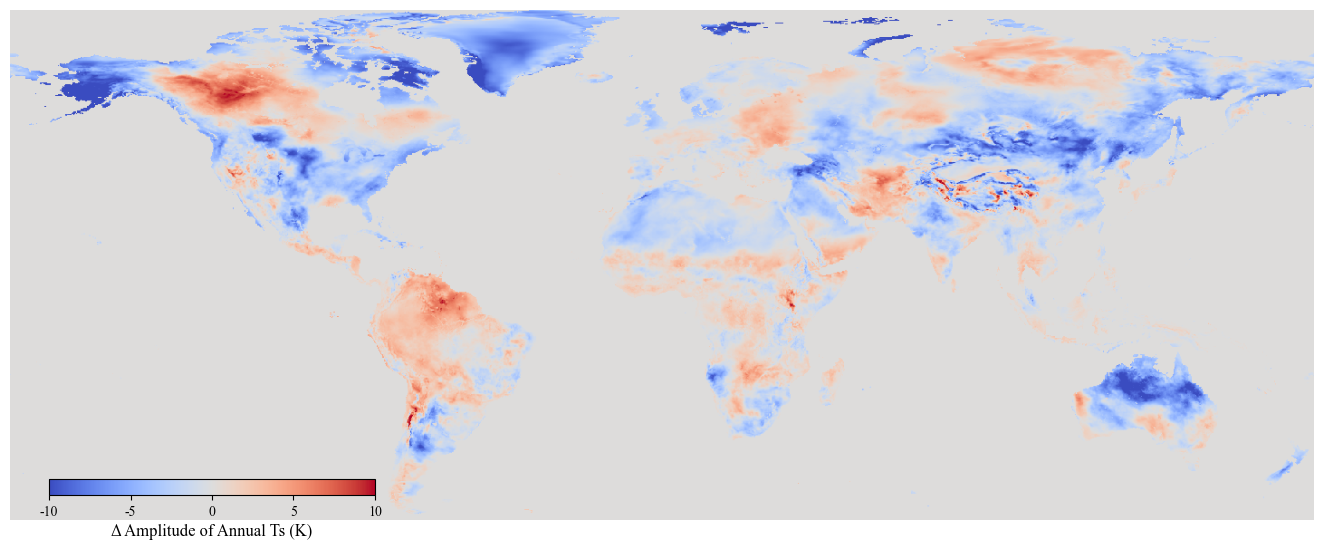

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 读取NC文件
ds = xr.open_dataset('/content/drive/My Drive/Science/Ts_2000-2024_monthly.nc')  #读取降水数据
Ts = ds['Ts']
real_times = pd.date_range(start='2000-01-01', periods=300, freq='MS')
Ts['time'] = real_times

# 2. 将月降水量转换为年降水总量
# 使用 groupby 按年分组，并对每个年份内的月份求和
annual_Ts = Ts.groupby('time.year').sum(dim='time')

# 3. 划分时间段
period1_annual = annual_Ts.sel(year=slice(2000, 2021))  # 2000-2021年
period2_annual = annual_Ts.sel(year=slice(2022, 2024))  # 2022-2024年

# 4. 计算年际变化幅度（标准差）
std_2000_2021 = period1_annual.std(dim='year')
std_2022_2024 = period2_annual.std(dim='year')

# 5. 计算变化幅度的差值（后期减前期）
# 正值(红色)代表 2022-2024 年波动变大（极端化），负值(蓝色)代表波动变小
difference_std = std_2022_2024 - std_2000_2021

plt.rcParams['font.serif'] = "Times New Roman"
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = "serif"
plt.rcParams['axes.unicode_minus'] = False

# 绘图
fig, ax = plt.subplots(figsize=(14.4, 5.64))

im = ax.imshow(difference_std, cmap='coolwarm', vmin=-10, vmax=10)
ax.axis('off')

cax = ax.inset_axes([0.03, 0.05, 0.25, 0.03])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')

cbar.set_label('Δ Amplitude of Annual Ts (K)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
#plt.savefig('2000-2021vs2022-2024_Ts_Amplitude.png', dpi=300, bbox_inches='tight')
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


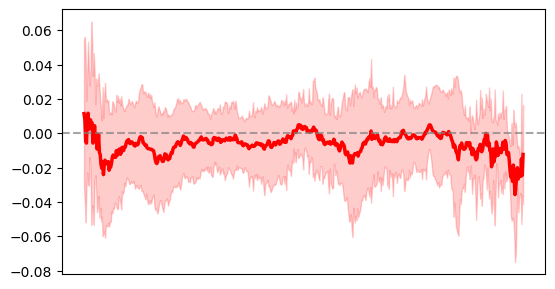

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


# 读取NC文件
ds = xr.open_dataset('/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc')
soil_moisture = ds['soil_moisture']

# 划分时间段（基于时间索引）
period1 = soil_moisture.isel(time=slice(0, 264))  # 2000-2021年（264个月）
period2 = soil_moisture.isel(time=slice(264, 300))  # 2022-2024年（36个月）

# 计算各时段平均值
mean_2000_2021 = period1.mean(dim='time')
mean_2022_2024 = period2.mean(dim='time')

# 计算差值（后期减前期）
difference = mean_2022_2024 - mean_2000_2021

# 计算经度平均值
lat_mean = difference.mean(dim='x')
lat_std = difference.std(dim='x')    # 经度标准差

# 创建图形
plt.figure(figsize=(5.65, 3))

# 绘制纬度平均曲线
plt.plot(lat_mean, 'r-', linewidth=2.5)
# 添加标准差曲线（置信区间带）
plt.fill_between(        lat_mean['y'],
                 lat_mean - lat_std,
                 lat_mean + lat_std,
                 color='red', alpha=0.2)

# 添加零参考线
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7)  #经度的平均

# 美化图表
#plt.axis('off')  # 关闭所有坐标轴和边框
plt.gca().xaxis.set_visible(False)  # 关键步骤
plt.tight_layout()

# 显示图表
plt.savefig('2000-2021vs2022-2024_lat.png', dpi=300)
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


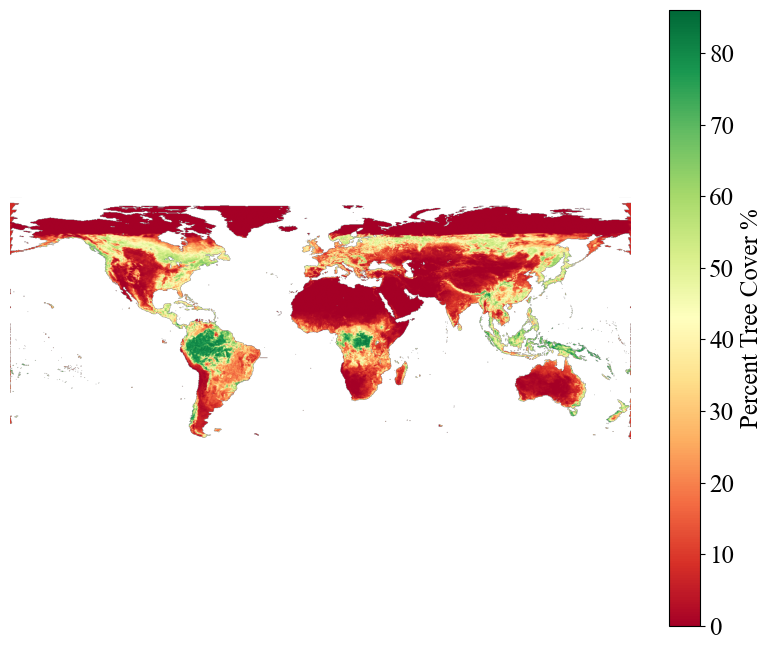

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import matplotlib.pyplot as plt

def display_raw_image():
    # 读取NC文件
    ds = xr.open_dataset('/content/drive/My Drive/Science/preTree_2000-2024_yearly.nc')
    #ds = xr.open_dataset('/content/drive/My Drive/Science/dmv_2000-2024_monthly.nc')

    # 直接提取森林覆盖数据
   # img_data = ds['preTree'][24].values-ds['preTree'][21].values  # 假设需要显示第一个时间层
    img_data = ds['preTree'][24].values
    # 创建图形（关闭坐标轴）
    plt.rcParams['font.size'] = 18
    plt.figure(figsize=(10, 8))
    plt.imshow(img_data, cmap='RdYlGn')
    plt.axis('off')  # 关闭所有坐标轴和边框
    plt.colorbar(label='Percent Tree Cover %')
    plt.show()

if __name__ == '__main__':
    display_raw_image()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import numpy as np
from scipy.interpolate import griddata
from tqdm import tqdm  # 进度条库

# 1. 读取数据
ds = xr.open_dataset("/content/drive/My Drive/Science/calibrated_soil_moisture_2000-2024_new.nc")
soil_moisture = ds["soil_moisture"]  # 假设变量名为'sm'

# 2. 创建海洋掩膜（永久性空值区域）
def create_ocean_mask(da):
    """创建海洋掩膜：在整个时间序列上都是NaN的区域"""
    # 计算每个网格点在整个时间序列上是否全为NaN
    ocean_mask = da.isnull().all(dim="time")
    return ocean_mask

OCEAN_MASK = create_ocean_mask(soil_moisture)

# 2. 时间维度线性插值（处理时间连续缺失）
def time_interpolate(da):
    """时间插值，但跳过海洋区域"""

    # 仅对非海洋区域进行插值
    non_ocean = da.where(~OCEAN_MASK)
    interpolated = non_ocean.interpolate_na(dim="time", method="linear", fill_value="extrapolate")

    # 恢复海洋区域的NaN值
    return interpolated.where(~OCEAN_MASK, da)

# 3. 空间维度IDW插值（处理空间孤立缺失）
def space_idw_interp(da):
    """处理三维数组的空间插值"""

    # 确保是三维数组 (time, y, x)
    if da.ndim != 3:
        raise ValueError(f"需要三维数组，但传入维度为{da.ndim}")

    # 初始化结果数组
    result = da.values.copy()

    # 获取时间维度大小
    time_size = da.sizes['time']

    # 创建进度条
    progress_bar = tqdm(total=time_size, desc="空间插值进度", unit="时间片")

    # 对每个时间点单独处理
    for t_idx in range(da.sizes['time']):
        # 获取当前时间片
        data_slice = da.isel(time=t_idx).values

        # 创建有效值坐标网格
        # 创建有效值掩膜（非海洋且非缺失）
        valid_mask = ~np.isnan(data_slice) & ~OCEAN_MASK.values
        # 创建需要插值的掩膜（非海洋但缺失）
        fill_mask = np.isnan(data_slice) & ~OCEAN_MASK.values
        coords = np.where(valid_mask)

        # 处理退化情况
        if len(coords[0]) == 0:  # 没有有效点
            result[t_idx] = data_slice  # 保留原始NaN
            continue

        if len(coords) == 2:  # 二维情况
            y_indices, x_indices = coords
            points = np.column_stack((y_indices, x_indices))
        else:  # 三维情况
            # 直接使用前两个维度（忽略时间维度）
            y_indices, x_indices = coords[1], coords[2]
            points = np.column_stack((y_indices, x_indices))

        values = data_slice[valid_mask]

        # 检查退化情况（所有点x坐标相同）
        if len(points) > 0 and np.all(points[:, 1] == points[0, 1]):
            print(f"警告：时间 {da.time.values[t_idx]} 存在退化情况，跳过填补")
            result[t_idx] = data_slice  # 保留原始NaN
            continue

        # 检查有效点数量
        if len(points) < 3:
            print(f"警告：时间 {da.time.values[t_idx]} 有效点不足，跳过填补")
            result[t_idx] = data_slice  # 保留原始NaN
            continue

        # 执行IDW插值
        grid_y, grid_x = np.meshgrid(
            np.arange(data_slice.shape[0]),
            np.arange(data_slice.shape[1]),
            indexing='ij'
        )
        target_points = np.column_stack((grid_y.ravel(), grid_x.ravel()))

        interp_vals = griddata(
            points, values, target_points,
            method='linear', fill_value=np.nan
        ).reshape(data_slice.shape)

        result[t_idx][fill_mask] = interp_vals[fill_mask]

    return xr.DataArray(
        result,
        dims=da.dims,
        coords=da.coords
    )

# 4. 时空联合插值流程
def spatiotemporal_fill(da):

    # 第一步：时间插值
    temp_filled = da.groupby("y").apply(time_interpolate)

    # 第二步：空间IDW插值
    final_filled = temp_filled.groupby("time").apply(space_idw_interp)

    final_filled = final_filled.where(~OCEAN_MASK)

    # 强制约束到[0,1]范围
    return final_filled.clip(min=0, max=1)

# 5. 执行插值并保存
filled_data = spatiotemporal_fill(soil_moisture)
filled_data.to_netcdf("/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc")

print("缺失值填补完成！新数据已保存至 processed_soil_moisture_2000-2024.nc")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- 全球整体 RMSE 评估结果 ---
产品 A 全球平均 RMSE: 0.04706
产品 B 全球平均 RMSE: 0.05460
产品 C 全球平均 RMSE: 0.06004


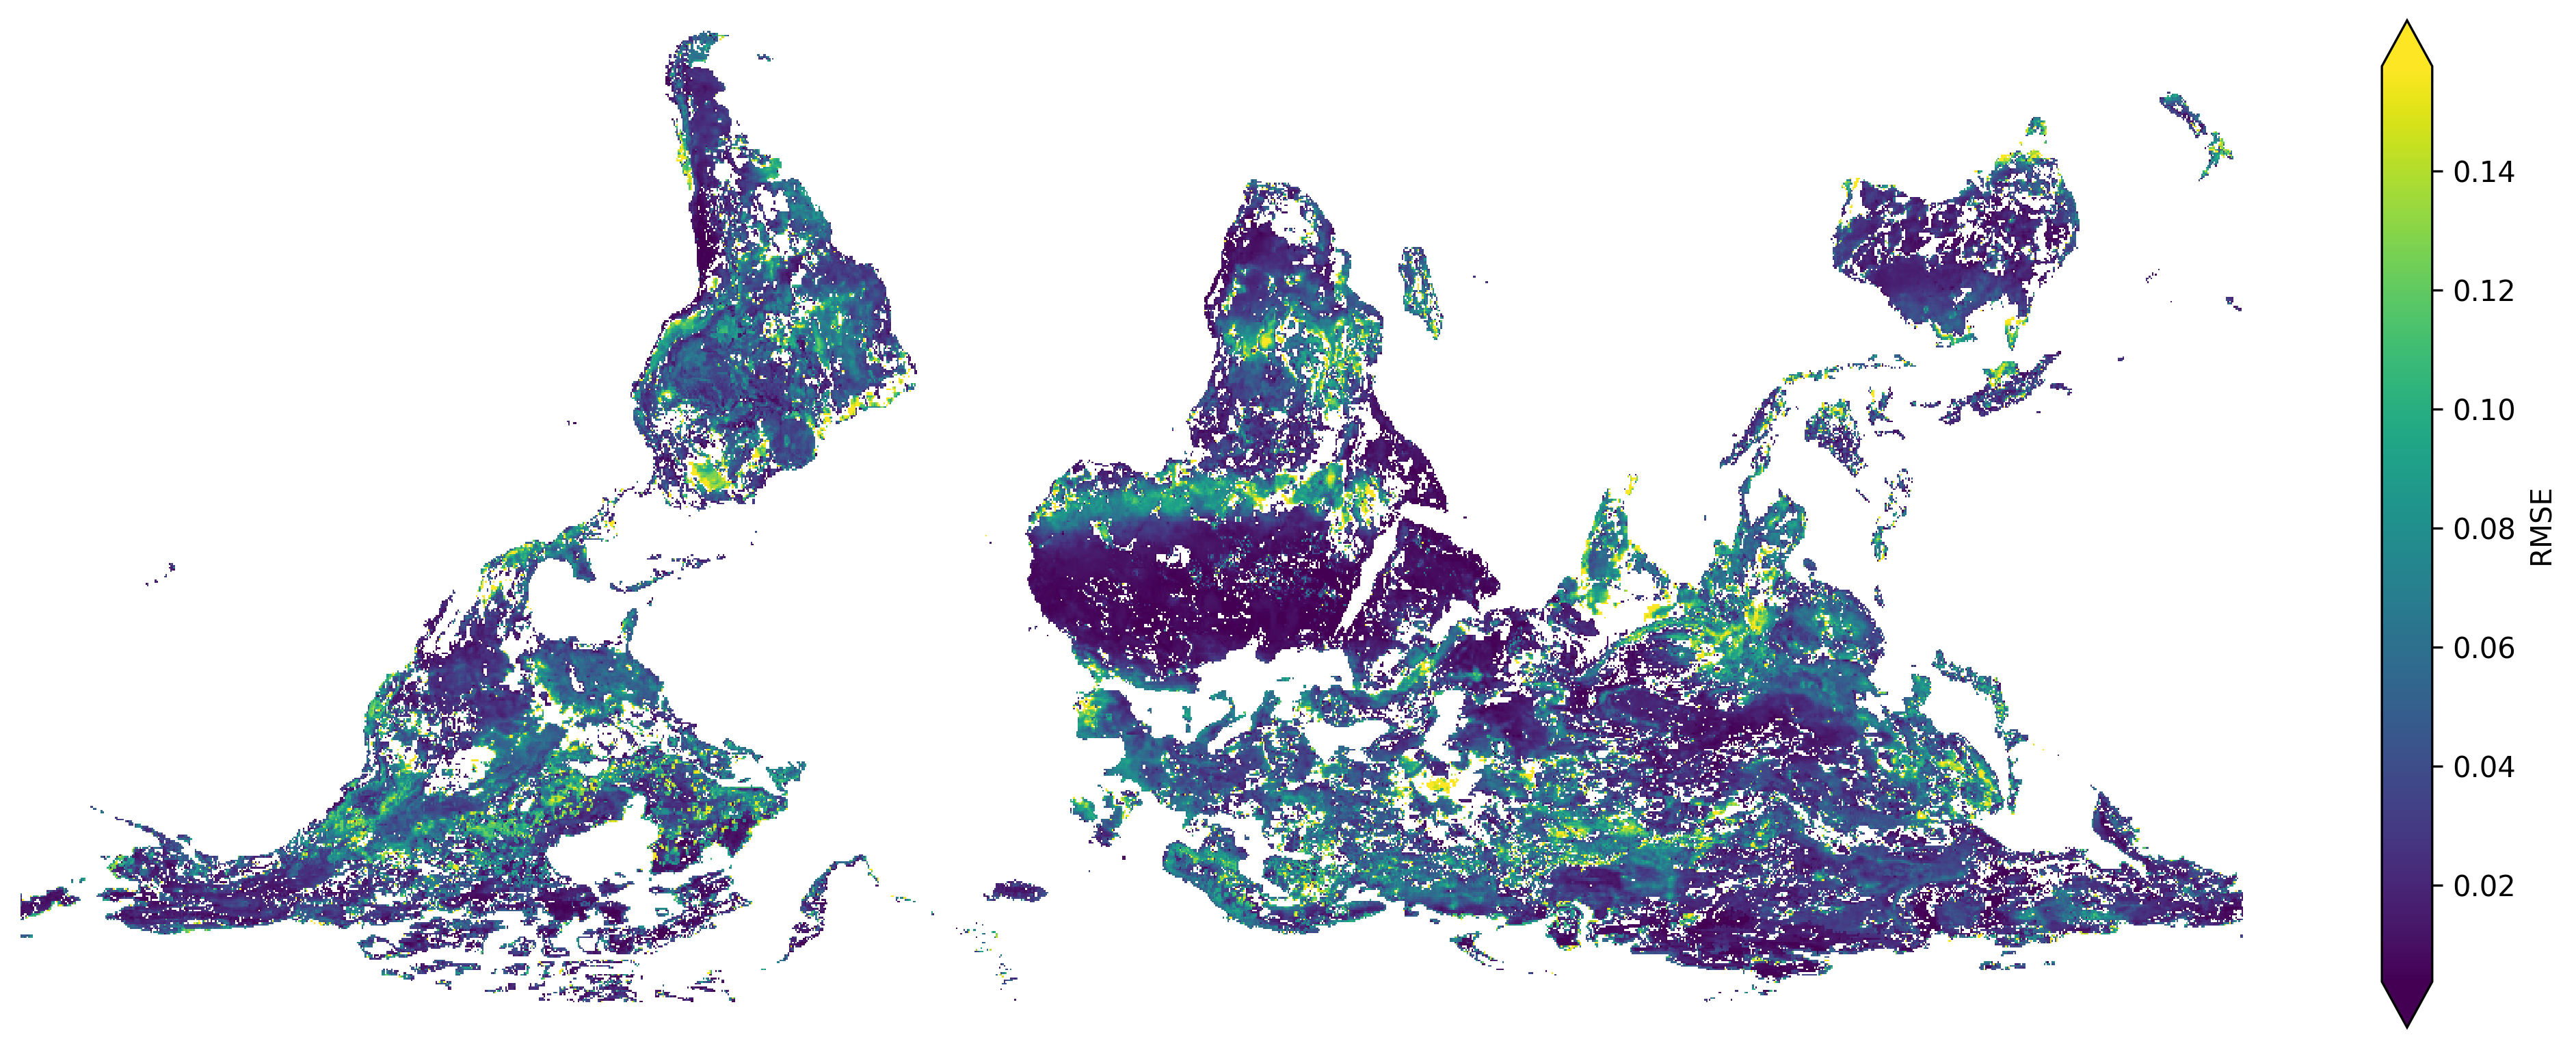

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 数据读取与预处理
# ==========================================
var_name = 'sm'

# 读取三个 NC 文件
ds_A = xr.open_dataset('/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc')['soil_moisture']
ds_B = xr.open_dataset('/content/drive/My Drive/Science/ESA_2015-2024_monthly.nc')['soil_moisture']
ds_C = xr.open_dataset('/content/drive/My Drive/Science/GLDASSM_2000-2024_monthly.nc')['soil_moisture']

# 假设它们的时间步和空间格网已经完全一致
# 为了避免含有 NaN 的像元干扰计算，可以在时间维度上提取有效掩膜 (mask)
valid_mask = ds_A.notnull() & ds_B.notnull() & ds_C.notnull()
ds_A = ds_A.where(valid_mask)
ds_B = ds_B.where(valid_mask)
ds_C = ds_C.where(valid_mask)

# ==========================================
# 2. 计算距平 (Anomalies) 与 协方差 (Covariances)
# ==========================================
# 计算时间平均值
mean_A = ds_A.mean(dim='time', skipna=True)
mean_B = ds_B.mean(dim='time', skipna=True)
mean_C = ds_C.mean(dim='time', skipna=True)

# 计算距平（Anomalies）
anom_A = ds_A - mean_A
anom_B = ds_B - mean_B
anom_C = ds_C - mean_C

# 计算方差 (Variances)
var_A = ds_A.var(dim='time', skipna=True)
var_B = ds_B.var(dim='time', skipna=True)
var_C = ds_C.var(dim='time', skipna=True)

# 计算协方差 (Covariances)
# Cov(X, Y) = Mean( (X - Mean(X)) * (Y - Mean(Y)) )
cov_AB = (anom_A * anom_B).mean(dim='time', skipna=True)
cov_AC = (anom_A * anom_C).mean(dim='time', skipna=True)
cov_BC = (anom_B * anom_C).mean(dim='time', skipna=True)

# ==========================================
# 3. Triple Collocation 计算误差方差与 RMSE
# ==========================================
# 基于 TC 理论计算各产品的误差方差 (Error Variance)
err_var_A = var_A - (cov_AB * cov_AC) / cov_BC
err_var_B = var_B - (cov_AB * cov_BC) / cov_AC
err_var_C = var_C - (cov_AC * cov_BC) / cov_AB

# 处理负方差现象：
# TC 在样本量不足或不满足独立误差假设时，部分格网可能计算出负方差。
# 在物理上误差方差不能为负，故将其滤除（设置为 NaN）。
err_var_A = err_var_A.where(err_var_A > 0)
err_var_B = err_var_B.where(err_var_B > 0)
err_var_C = err_var_C.where(err_var_C > 0)

err_var_A = xr.where(np.isinf(err_var_A), np.nan, err_var_A)
err_var_B = xr.where(np.isinf(err_var_B), np.nan, err_var_B)
err_var_C = xr.where(np.isinf(err_var_C), np.nan, err_var_C)

# 计算 RMSE
rmse_A = np.sqrt(err_var_A)
rmse_B = np.sqrt(err_var_B)
rmse_C = np.sqrt(err_var_C)

# ==========================================
# 4. 计算并输出全球整体误差值 RMSE
# ==========================================
# 对所有空间格网取平均值，得到单一的全球 RMSE 值
global_rmse_A = float(rmse_A.mean(skipna=True).values)
global_rmse_B = float(rmse_B.mean(skipna=True).values)
global_rmse_C = float(rmse_C.mean(skipna=True).values)

print(f"--- 全球整体 RMSE 评估结果 ---")
print(f"产品 A 全球平均 RMSE: {global_rmse_A:.5f}")
print(f"产品 B 全球平均 RMSE: {global_rmse_B:.5f}")
print(f"产品 C 全球平均 RMSE: {global_rmse_C:.5f}")

# ==========================================
# 5. 生成并保存产品 A 的全球误差图
# ==========================================
plt.figure(figsize=(14.4, 5.64), dpi=300)

# 绘制 RMSE 空间分布图，由于不包含经纬度，直接使用 y, x 索引绘图
# robust=True 可以自动忽略两端极端值，使得颜色分布更合理
rmse_A.plot(cmap='viridis', robust=True, cbar_kwargs={'label': 'RMSE'})
plt.tight_layout()
plt.axis('off')  # 关闭所有坐标轴和边框

# 保存图像并显示
plt.savefig('Product_A_RMSE_Map.png')
plt.show()

# 关闭文件释放内存
ds_A.close()
ds_B.close()
ds_C.close()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime, timezone, timedelta

# 1. 加载土壤湿度数据
# 假设数据已保存为NetCDF格式
ds1 = xr.open_dataset('/content/drive/My Drive/Science/SSM_2000-2024_monthly.nc')
sm1 = ds1['soil_moisture']  # 维度: (time, y, x)

ds2 = xr.open_dataset('/content/drive/My Drive/Science/SMAP_2015-2024_monthly.nc')
sm2 = ds2['soil_moisture']  # 维度: (time, y, x)

ds3 = xr.open_dataset('/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc') #calibrated processed
sm3 = ds3['soil_moisture']  # 维度: (time, y, x)

print(f"数据加载完成")


# 3. 计算月平均值
# 自动识别空间维度（排除时间维度）

#monthly_avg1 = sm1.mean(dim=['y', 'x'])
#monthly_avg2 = sm2.mean(dim=['y', 'x'])
#monthly_avg3 = sm3.mean(dim=['y', 'x'])
monthly_avg1 = sm1.isel(y=200, x=800)
monthly_avg2 = sm2.isel(y=200, x=800)
monthly_avg3 = sm3.isel(y=200, x=800)

# 4. 转换为Pandas时间序列
dates1 = pd.date_range(start='2000-01-01', periods=300, freq='MS')  # MS=每月开始
# 第二组：2015年4月到2024年12月（共117个月）
dates2 = pd.date_range(start='2015-04-01', periods=117, freq='MS')
dates3 = pd.date_range(start='2000-01-01', periods=300, freq='MS')  # MS=每月开始

# 5. 创建带时间索引的Pandas Series
ts1 = pd.Series(monthly_avg1.values, index=dates1, name='Soil Moisture')
ts2 = pd.Series(monthly_avg2.values, index=dates2, name='Soil Moisture')
ts3 = pd.Series(monthly_avg3.values, index=dates3, name='Soil Moisture')

# 5. 创建对比图表
plt.figure(figsize=(16, 8))

# 绘制第一组数据 (2000-2024)
ts1.plot(label='ERA5-Land (2000-2024)', color='royalblue', linewidth=2.5, alpha=0.8)

# 绘制第二组数据 (2015-2024)
ts2.plot(label='DM SSM (2015-2024)', color='darkorange', linewidth=2.5, linestyle='--')

# 绘制第三组数据 (2000-2024)
ts3.plot(label='Calibrated SSM (2000-2024)', color='seagreen', linewidth=3.0, linestyle='dotted')

# 设置图表元素
plt.title(f'Global Monthly Soil Moisture Comparison',
          fontsize=16, pad=20)
plt.ylabel('Soil Moisture ($m^3/m^3$)', fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.grid(alpha=0.2, linestyle='--')
plt.legend(fontsize=12, loc='upper right')
plt.xticks(rotation=45)

# 添加重叠区域高亮 (2015-2024)
dataset_start = '2000-01-01'
overlap_start = '2015-04-01'
overlap_end = '2024-12-31'
plt.axvspan(overlap_start, overlap_end, alpha=0.1, color='green', label='Overlap Region')

# 添加统计信息框
stats_text = f"Overlap Period (2015-2024) Statistics:\n" \
             f"ERA5-Land Mean: {ts1[dataset_start:overlap_end].mean():.4f}\n" \
             f"DM SSM Mean: {ts2[overlap_start:overlap_end].mean():.4f}\n" \
             f"Calibrated SSM Mean: {ts3[dataset_start:overlap_end].mean():.4f}\n" \
             f"Correlation: {ts1[dataset_start:overlap_end].corr(ts3[dataset_start:overlap_end]):.4f}"
plt.annotate(stats_text, xy=(0.02, 0.85), xycoords='axes fraction',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
             fontsize=11)

plt.tight_layout()

# 6. 保存结果
#plt.savefig('soil_moisture_comparison.png', dpi=300, bbox_inches='tight')
#ts1.to_csv('dataset1_monthly_avg.csv')
#ts2.to_csv('dataset2_monthly_avg.csv')
plt.show()


In [ ]:
import os
import warnings
import tempfile
import numpy as np
import pandas as pd
import xarray as xr
import lightgbm as lgb
from google.colab import drive

warnings.filterwarnings('ignore')

# ========== 1. 挂载与路径配置 ==========
drive.mount('/content/drive')

BASE_PATH = '/content/drive/My Drive/Science'
PATH_SSM = f'{BASE_PATH}/SSM_2000-2024_monthly.nc'
PATH_LST = f'{BASE_PATH}/LST_2000-2024_monthly.nc'
PATH_EVI = f'{BASE_PATH}/EVI_2000-2024_monthly.nc'
PATH_PREP = f'{BASE_PATH}/Precip_2000-2024_monthly.nc'
PATH_SM = f'{BASE_PATH}/SM_2015-2024_monthly.nc'
OUTPUT_PATH = f'{BASE_PATH}/calibrated_soil_moisture_2000-2024.nc'

# ========== 2. 数据加载与对齐 ==========
print("加载所有特征数据集...")
# 分块读取，优化内存
chunk_size = {'time': 24, 'x': 200, 'y': 200}

ds_ssm = xr.open_dataset(PATH_SSM, chunks=chunk_size)
ds_lst = xr.open_dataset(PATH_LST, chunks=chunk_size)
ds_evi = xr.open_dataset(PATH_EVI, chunks=chunk_size)
ds_prep = xr.open_dataset(PATH_PREP, chunks=chunk_size)
ds_sm = xr.open_dataset(PATH_SM, chunks=chunk_size)

# 构建统一的时间和空间坐标
trend_times = pd.date_range(start='2000-01', end='2024-12', freq='MS')
true_times = pd.date_range(start='2015-04', end='2024-12', freq='MS')

x_dim, y_dim = ds_ssm.dims['x'], ds_ssm.dims['y']
x_coords, y_coords = np.arange(x_dim), np.arange(y_dim)

# 重置并合并预测变量集 (X)
def prepare_coords(ds, times):
    return ds.assign_coords(time=times, x=x_coords, y=y_coords)

ds_ssm = prepare_coords(ds_ssm, trend_times)
ds_lst = prepare_coords(ds_lst, trend_times)
ds_evi = prepare_coords(ds_evi, trend_times)
ds_prep = prepare_coords(ds_prep, trend_times)
ds_sm = prepare_coords(ds_sm, true_times)

# 合并特征数据集 (确保数据变量名称对应正确)
ds_features = xr.Dataset({
    'ssm': ds_ssm['soil_moisture'],
    'lst': ds_lst['lst'],            # 请根据实际文件中的变量名修改
    'evi': ds_evi['evi'],            # 请根据实际文件中的变量名修改
    'prep': ds_prep['precipitation']  # 请根据实际文件中的变量名修改
})

# 特征列定义
feature_cols = ['ssm', 'lst', 'evi', 'prep', 'x', 'y']
target_col = 'sm'

# ========== 3. 训练 LightGBM 模型 (按月建模) ==========
print("提取重叠期数据训练 LightGBM 模型...")
overlap_start, overlap_end = '2015-04', '2024-12'

# 截取重叠期
features_overlap = ds_features.sel(time=slice(overlap_start, overlap_end))
sm_overlap = ds_sm['soil_moisture'].sel(time=slice(overlap_start, overlap_end))

models = {}  # 存储12个月份的模型

# 超参数配置
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'n_estimators': 300,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

for month in range(1, 13):
    print(f"处理 {month} 月模型训练 ...")

    # 按月份筛选数据
    f_month = features_overlap.sel(time=features_overlap['time.month'] == month)
    t_month = sm_overlap.sel(time=sm_overlap['time.month'] == month)

    # 转换为 DataFrame 方便表格建模
    df_f = f_month.to_dataframe().reset_index()
    df_t = t_month.to_dataframe(name=target_col).reset_index()

    # 合并特征与目标值
    df_train = pd.merge(df_f, df_t, on=['time', 'x', 'y']).dropna(subset=feature_cols + [target_col])

    if len(df_train) < 100:
        print(f"警告: {month} 月有效数据样本不足，跳过拟合。")
        continue

    X_train = df_train[feature_cols]
    y_train = df_train[target_col]

    # 训练模型
    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(X_train, y_train)
    models[month] = model

# ========== 4. 应用模型校正历史数据 (2000-01 至 2015-03) ==========
print("校正历史数据...")
features_hist = ds_features.sel(time=slice('2000-01', '2015-03'))

temp_dir = tempfile.TemporaryDirectory()
historical_calib_paths = []

for month in range(1, 13):
    if month not in models:
        continue

    print(f"校正 {month} 月历史数据...")
    hist_m = features_hist.sel(time=features_hist['time.month'] == month)

    # 转为 DataFrame 进行批量预测
    df_hist_m = hist_m.to_dataframe().reset_index()

    # 记录原始索引与 NaN 掩码
    valid_mask = df_hist_m[feature_cols].notna().all(axis=1)

    # 预测数组初始化为 NaN
    predictions = np.full(len(df_hist_m), np.nan)

    if valid_mask.sum() > 0:
        X_pred = df_hist_m.loc[valid_mask, feature_cols]
        predictions[valid_mask] = models[month].predict(X_pred)

    df_hist_m['calibrated_sm'] = predictions

    # 重构为 3D DataArray (time, x, y)
    da_calibrated = df_hist_m.set_index(['time', 'x', 'y'])['calibrated_sm'].to_xarray()

    # 保存至临时文件释放内存
    temp_path = os.path.join(temp_dir.name, f'hist_month_{month}.nc')
    da_calibrated.to_netcdf(temp_path)
    historical_calib_paths.append(temp_path)

# ========== 5. 数据拼接与导出 =========
print("构建完整数据集...")
# 合并历史预测数据
historical_combined = xr.concat(
    [xr.open_dataarray(path) for path in historical_calib_paths],
    dim='time'
).sortby('time')

# 拼接 SM 数据 (2015-04 至 2024-12)
sm_true_da = ds_sm['soil_moisture']
full_series = xr.concat([historical_combined, sm_true_da], dim='time').sortby('time')

# 转为标准的 Dataset 格式
full_ds = xr.Dataset({'soil_moisture': full_series})

# 编码压缩配置
encoding = {
    'soil_moisture': {
        'zlib': True,
        'complevel': 5,
        'dtype': 'float32'
    }
}

print("保存最终结果...")
full_ds.to_netcdf(OUTPUT_PATH, encoding=encoding)

# 释放临时内存
temp_dir.cleanup()

print(f"数据融合完成! 结果已保存至 {OUTPUT_PATH}")




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
当前北京时间: 2025-09-17 17:49:49
加载数据集...
创建时间索引...
训练校正模型...
处理 1月模型训练...
处理 2月模型训练...
处理 3月模型训练...
处理 4月模型训练...
处理 5月模型训练...
处理 6月模型训练...
处理 7月模型训练...
处理 8月模型训练...
处理 9月模型训练...
处理 10月模型训练...
处理 11月模型训练...
处理 12月模型训练...
校正历史数据...
校正 1月历史数据...
校正 2月历史数据...
校正 3月历史数据...
校正 4月历史数据...
校正 5月历史数据...
校正 6月历史数据...
校正 7月历史数据...
校正 8月历史数据...
校正 9月历史数据...
校正 10月历史数据...
校正 11月历史数据...
校正 12月历史数据...
构建完整数据集...
保存最终结果...
数据融合完成! 结果已保存至 /content/drive/My Drive/Nature/calibrated_soil_moisture_2000-2024.nc
数据集时间范围: 2000-01-01T00:00:00.000000000 至 2024-12-01T00:00:00.000000000


In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import xarray as xr
from statsmodels.tsa.seasonal import STL
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.fft import fft
import matplotlib.pyplot as plt
import dask
import dask.array as da
from dask.diagnostics import ProgressBar

# 1. 加载土壤湿度数据
# 假设数据已保存为NetCDF格式
ds = xr.open_dataset('/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc')
sm_data = ds['soil_moisture']  # 维度: (time, y, x)

print(f"数据加载完成，维度: time={len(sm_data.time)}, y={len(sm_data.y)}, x={len(sm_data.x)}")

# 2. 定义STL分解函数
def stl_decomposition(ts, period=12):
    """对时间序列进行STL分解"""
    # 处理缺失值
    if np.isnan(ts).all():
        return np.full(len(ts), np.nan), np.full(len(ts), np.nan)

    # 执行STL分解
    stl = STL(ts, period=period, robust=True)
    res = stl.fit()
    return res.trend, res.seasonal

# 3. 定义特征提取函数
def extract_features(trend, seasonal):
    """从趋势和季节分量中提取特征"""
    # 特征1: 趋势斜率 (线性回归)
    x = np.arange(len(trend))
    mask = ~np.isnan(trend)
    if np.sum(mask) < 5:  # 至少需要5个点
        slope = np.nan
    else:
        slope = np.polyfit(x[mask], trend[mask], 1)[0]

    # 特征2: 季节振幅 (最大值与最小值的差)
    seasonal_amp = np.nanmax(seasonal) - np.nanmin(seasonal) if not np.isnan(seasonal).all() else np.nan

    # 特征3: 季节相位 (峰值位置)
    seasonal_phase = np.argmax(seasonal) % 12 if not np.isnan(seasonal).all() else np.nan

    # 特征4: 趋势均值
    trend_mean = np.mean(trend) if not np.isnan(trend).all() else np.nan


    return np.array([slope, seasonal_amp, seasonal_phase, trend_mean])

# 4. 对每个网格点应用STL分解和特征提取
# 使用dask进行并行计算加速
def process_pixel(ts):
    trend, seasonal = stl_decomposition(ts)
    features = extract_features(trend, seasonal)
    return features

# 将数据转换为dask array
sm_data_dask = da.from_array(sm_data.data, chunks=(len(sm_data.time), 100, 100))  # 按时间分块

# 为每个像素计算特征
features_dask = sm_data_dask.map_blocks(
    lambda block: np.apply_along_axis(process_pixel, 0, block),
    chunks=(4, *sm_data_dask.chunks[1:]),
    dtype=np.float32
)

# 计算特征
print("正在计算每个网格点的特征...")
with ProgressBar():
    features = features_dask.compute()

np.save('/content/drive/My Drive/Science/feature_new.npy', features)
print(f"原始特征数组已保存")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
数据加载完成，维度: time=300, y=564, x=1440
正在计算每个网格点的特征...
[########################################] | 100% Completed | 2hr 29m
原始特征数组已保存


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


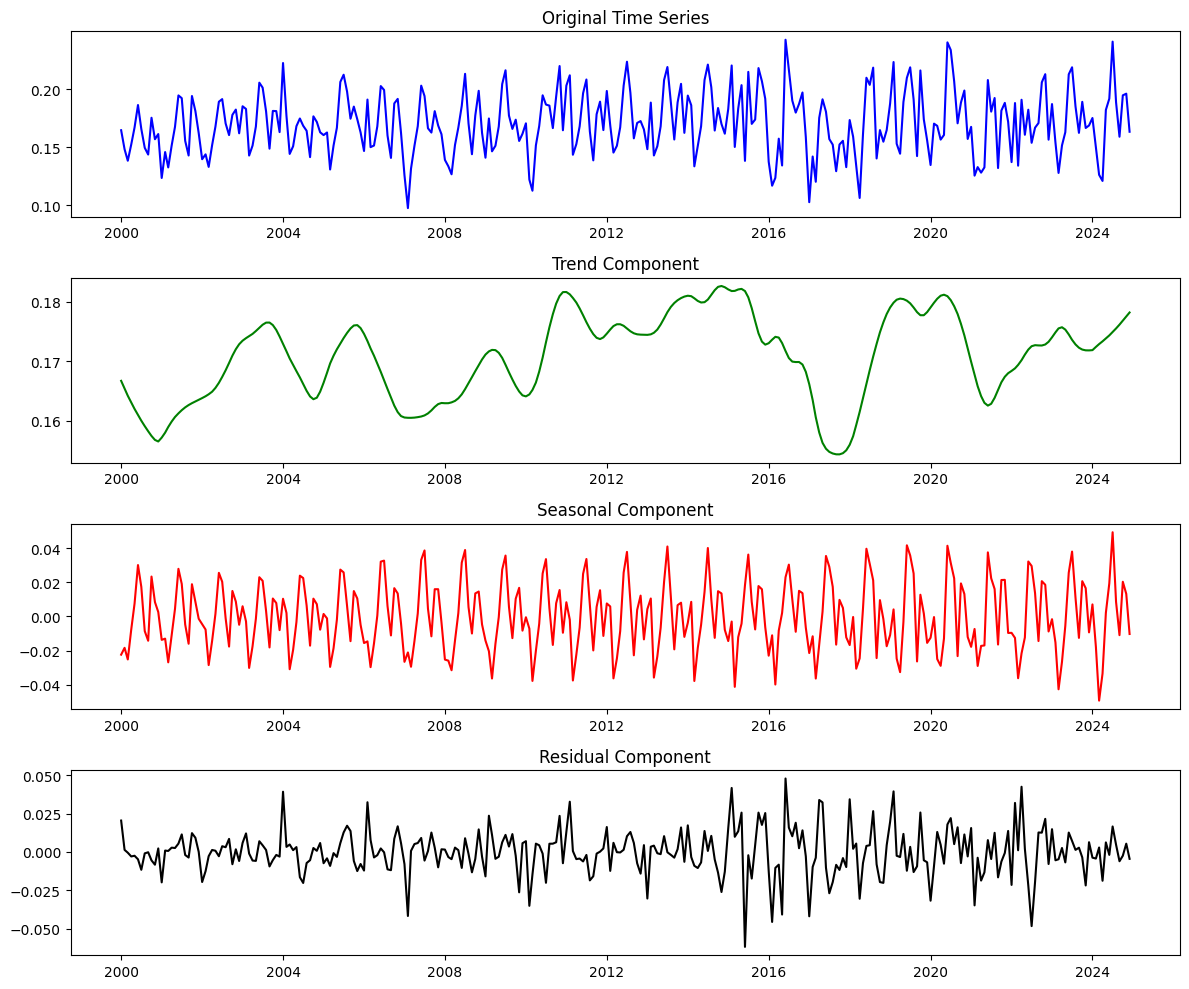


趋势分量特征（反映长期气候变化）:
趋势斜率: 0.0000
趋势波动性: -0.0000
干旱突变点: 213.0000
均值: 0.1708

季节分量特征（年周期规律）:
季节振幅: 0.0988
相位偏移: 6.0000
季节形态熵: -0.0061


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from scipy.fft import fft

# 1. 读取NetCDF文件
ds = xr.open_dataset('/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc')

# 2. 提取指定位置的时间序列 (y=200, x=1000)
time_series = ds['soil_moisture'].sel(y=200, x=1000, method='nearest')

# 3. 转换为Pandas时间序列
ts = time_series.to_pandas()

# 4. 处理缺失值（如有）
ts = ts.interpolate(method='linear')  # 线性插值填充缺失值

# 5. STL分解（季节性分解）
# 设置周期参数（根据数据特性调整，月数据=12，日数据=365）
stl = STL(ts, period=12)  # 假设是月数据
result = stl.fit()

# 6. 可视化结果
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10))

# 原始序列
ax1.plot(ts, 'b-')
ax1.set_title('Original Time Series')

# 趋势分量
ax2.plot(result.trend, 'g-')
ax2.set_title('Trend Component')

# 季节分量
ax3.plot(result.seasonal, 'r-')
ax3.set_title('Seasonal Component')

# 残差分量
ax4.plot(result.resid, 'k-')
ax4.set_title('Residual Component')

plt.tight_layout()
plt.savefig('stl_decomposition.png', dpi=300)
plt.show()

# 特征提取
trend = result.trend
trend_slope = np.polyfit(np.arange(len(trend)), trend, 1)[0]  # 趋势斜率 (%/十年)
trend_curvature = np.polyfit(np.arange(len(trend)), trend, 2)[0]  # 曲率(加速/减速)
dry_turning_point = np.argmin(trend)  # 最干旱转折年份
trend_mean = np.mean(trend)
print("\n趋势分量特征（反映长期气候变化）:")
print(f"趋势斜率: {trend_slope:.4f}")
print(f"趋势波动性: {trend_curvature:.4f}")
print(f"干旱突变点: {dry_turning_point:.4f}")
print(f"均值: {trend_mean:.4f}")

seasonal = result.seasonal
season_amp = seasonal.max() - seasonal.min()  # 季节振幅(%)
phase_shift = np.argmax(seasonal) % 12  # 湿润峰值月(1-12)
asymmetry = (seasonal[:6].mean() - seasonal[6:].mean())  # 季节不对称性
print("\n季节分量特征（年周期规律）:")
print(f"季节振幅: {season_amp:.4f}")
print(f"相位偏移: {phase_shift:.4f}")
print(f"季节形态熵: {asymmetry:.4f}")




In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import xarray as xr
from statsmodels.tsa.seasonal import STL
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.fft import fft
import matplotlib.pyplot as plt
import dask
import dask.array as da
from dask.diagnostics import ProgressBar

ds = xr.open_dataset('/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc')
sm_data = ds['soil_moisture']  # 维度: (time, y, x)

features = np.load('/content/drive/My Drive/Science/feature_new.npy')
print(f"原始特征数组已读取")

# 将特征数组转换为xarray DataArray
features_da = xr.DataArray(
    features,
    dims=('feature', 'y', 'x'),
    coords={
        'feature': ['trend_slope', 'seasonal_amplitude', 'seasonal_phase', 'trend_mean'],
        'y': sm_data.y,
        'x': sm_data.x
    }
)


# 5. 数据清洗和标准化
# 将特征转换为2D数组 (样本数 x 特征数)
valid_mask = ~np.isnan(features_da).any(dim='feature')
features_valid = features_da.stack(sample=('y', 'x')).transpose('sample', 'feature').dropna('sample')
X = features_valid.values

print(f"有效样本数: {len(X)}")

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. 确定最佳聚类数
print("确定最佳聚类数...")
silhouette_scores = []
k_range = range(3, 8)  # 测试3-7个聚类

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"聚类数: {k}, 轮廓系数: {score:.4f}")

# 选择轮廓系数最高的聚类数
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"最佳聚类数: {optimal_k} (轮廓系数: {max(silhouette_scores):.4f})")

# 7. 执行聚类
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 8. 将聚类结果映射回空间网格
cluster_map = features_da.isel(feature=0).copy()
cluster_map.values = np.full(cluster_map.shape, np.nan)
cluster_map.values[valid_mask.values] = clusters
cluster_map = cluster_map.sortby('y', ascending=False)  # 关键修改：反转y轴

# 9. 结果可视化
plt.figure(figsize=(14.4, 5.64))
cluster_map.plot(cmap='viridis', add_colorbar=True)
plt.title(f'Soil Moisture Regimes Clustering (k={optimal_k})')
plt.savefig('/content/drive/My Drive/Science/soil_moisture_clusters.png', dpi=300)
plt.show()

# 10. 保存聚类结果
cluster_map.to_netcdf('/content/drive/My Drive/Science/soil_moisture_clusters.nc')
print("聚类结果已保存为 soil_moisture_clusters.nc")

# 11. 分析每个聚类的特征
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
print("\n聚类中心特征值:")
for i, center in enumerate(cluster_centers):
    print(f"聚类 {i+1}:")
    print(f"  趋势斜率: {center[0]:.4f} (正值表示增加，负值表示减少)")
    print(f"  季节振幅: {center[1]:.4f} (值越大表示季节变化越剧烈)")
    print(f"  季节相位: {int(center[2])} (峰值出现的月份)")
    print(f"  趋势均值: {center[3]:.4f} (趋势均值)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


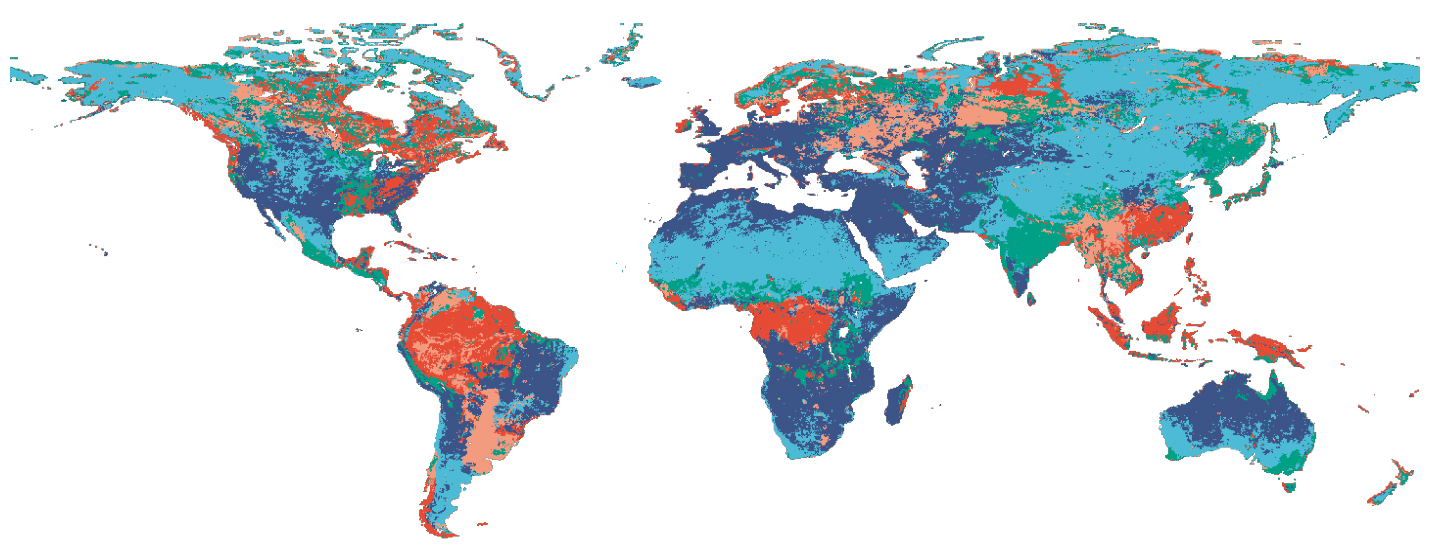

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors  # 导入色彩工具包
from datetime import datetime, timedelta

# 读取NC文件
ds = xr.open_dataset("/content/drive/My Drive/Science/soil_moisture_clusters.nc")

# 获取第一个数据变量（替换为你的变量名）
var_name = list(ds.data_vars)[0]
#print(var_name)
data = ds[var_name]

# 转换为纯二维数组
array_2d = data.values

#Nature官方标准学术配色
nature_colors = [
    '#4DBBD5',  # 天空蓝 (Sky Blue)
    '#00A087',  # 翡翠绿 (Teal/Green)
    '#E64B35',  # 经典朱红 (Red)
    '#3C5488',  # 经典深蓝 (Navy Blue)
    '#F39B7F'   # 浅橘/沙色 (Soft Orange)
]
# 创建离散色板
cmap_nature = mcolors.ListedColormap(nature_colors)

# 创建纯二维热力图
plt.figure(figsize=(14.4, 5.64))
im = plt.imshow(array_2d,
                cmap=cmap_nature,
                aspect='auto')  # 保持y轴方向一致

# 添加坐标轴标签
#plt.xlabel("X Dimension")
#plt.ylabel("Y Dimension")

plt.axis('off')  # 关闭所有坐标轴和边框


plt.tight_layout()
plt.savefig("/content/drive/My Drive/Science/soil_moisture_clusters.png", dpi=300)
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


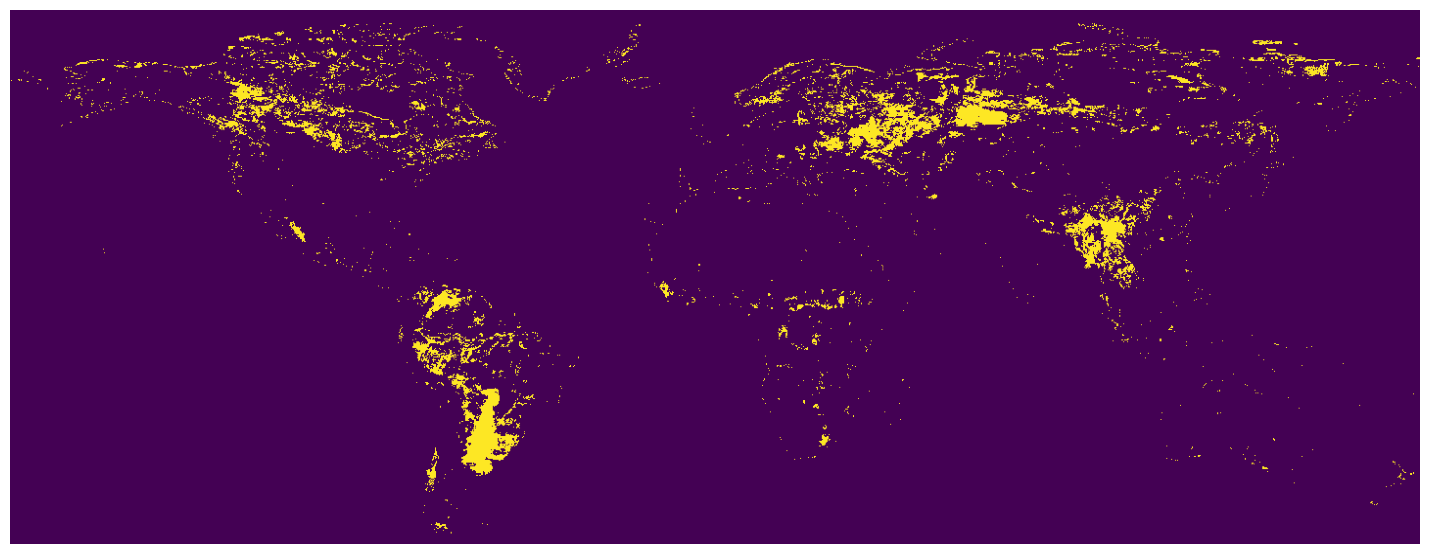

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import matplotlib.pyplot as plt

# 1. 读取原始文件
ds = xr.open_dataset('/content/drive/My Drive/Science/class_5.nc')

data = ds['class']

# 转换为纯二维数组
array_2d = data.values

# 创建纯二维热力图
plt.figure(figsize=(14.4, 5.64))
im = plt.imshow(array_2d,
                cmap='viridis',
                aspect='auto'
                )
plt.axis('off')  # 关闭所有坐标轴和边框

# 添加色标
#cbar = plt.colorbar(im)
#cbar.set_label('Class 5')
plt.savefig("soil_moisture_Class5.png", dpi=300)
plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


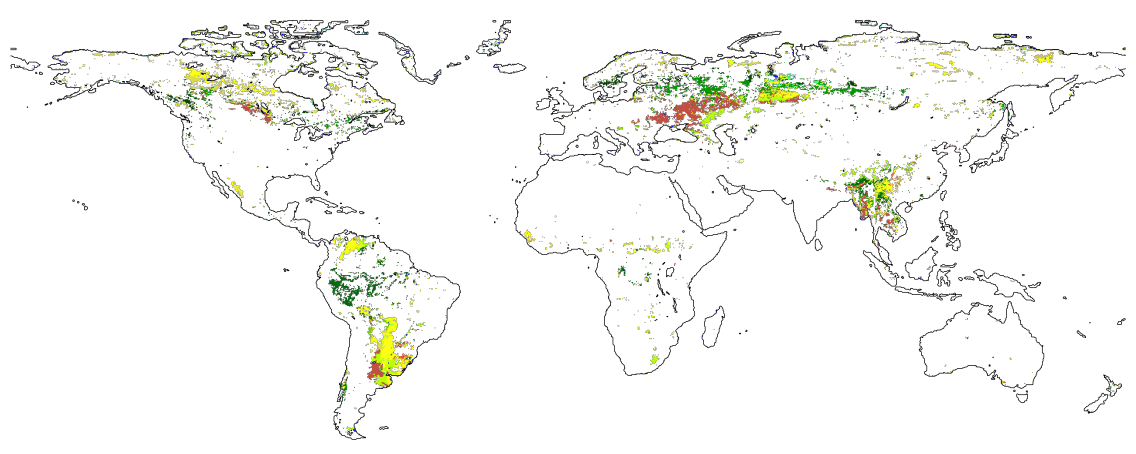

掩膜后的图像已保存为 'masked_landcover.png'！


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 步骤1: 加载NetCDF文件
# 假设文件在当前目录，如果路径不同，请修改
landcover_ds = xr.open_dataset('/content/drive/My Drive/Science/landcover_2001-2024_yearly.nc')  # 加载地表覆盖数据
class_ds = xr.open_dataset('/content/drive/My Drive/Science/class_5.nc')          # 加载掩膜数据
land_ds = xr.open_dataset('/content/drive/My Drive/Science/soil_moisture_clusters.nc')          # 加载掩膜数据
var_name = list(land_ds.data_vars)[0]

land = land_ds[var_name]
landcover = landcover_ds['landcover'][23]  # 地表覆盖数据，IGBP分类
class_mask = class_ds['class']         # 掩膜数据


# 步骤2: 应用掩膜
# 假设掩膜中1表示保留区域，0表示掩膜区域（设为NaN）
masked_landcover = landcover.where(class_mask == 1).values
binary_land = xr.where(land.notnull(), 1, 0)  # 陆地=1, 海洋/无效值=0

# 步骤3: 生成并保存图像
plt.figure(figsize=(14.4, 5.64))  # 设置图像大小

# 可视化掩膜后的数据 - 使用'viridis' colormap（通用，可自定义为IGBP专用）
igbp_cmap = ListedColormap(['#05450a', '#086a10', '#54a708', '#78d203', '#009900', '#c6b044', '#dcd159',
    '#dade48', '#fbff13', '#b6ff05', '#27ff87', '#c24f44', '#a5a5a5', '#ff6d4c',
    '#69fff8', '#f9ffa4', '#1c0dff'])
im = plt.imshow(masked_landcover,
                cmap=igbp_cmap,
                aspect='auto'
                )
contour = plt.contour(
    binary_land,
    levels=[0.5],       # 在0.5处绘制轮廓线
    colors='black',     # 边界颜色
    linewidths=0.5,     # 边界线宽
    linestyles='solid'  # 实线
)
#plt.title('Masked Global Land Cover (IGBP Classification)')
plt.axis('off')  # 关闭坐标轴，使图像更清晰

# 保存图像到文件
plt.savefig('masked_landcover_class5.png', dpi=300, bbox_inches='tight')  # 保存为PNG，高分辨率
plt.show()  # 显示图像

print("掩膜后的图像已保存为 'masked_landcover.png'！")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
土壤湿度分类比例:
0-0.1: 0.00%
0.1-0.2: 0.00%
0.2-0.3: 34.67%
0.3-0.4: 65.33%
0.4-0.5: 0.00%
0.5-0.6: 0.00%


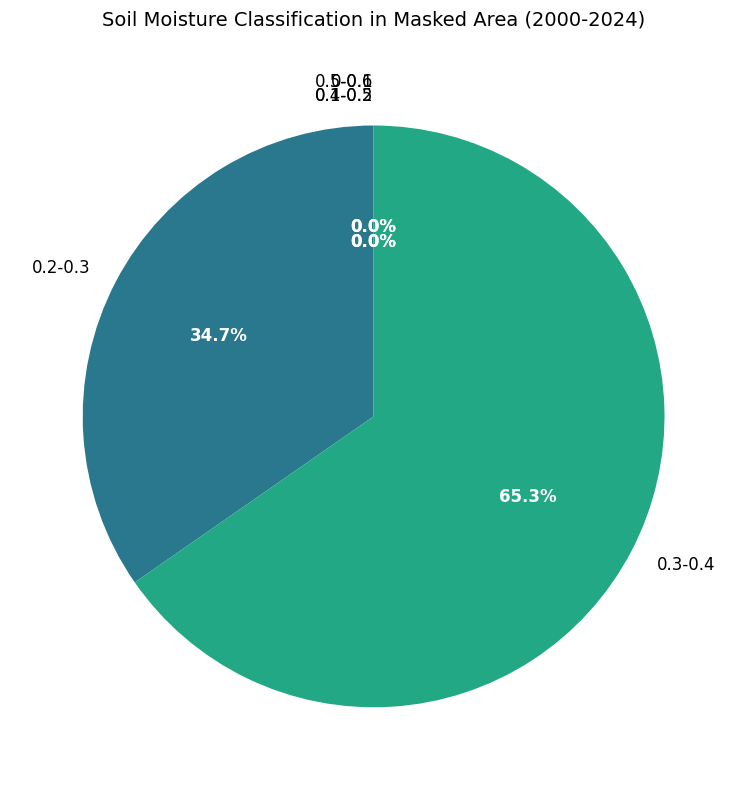

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 1. 读取数据
soil_ds = xr.open_dataset('/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc')
mask_ds = xr.open_dataset('/content/drive/My Drive/Science/class_5.nc')

# 2. 应用掩膜
mask = mask_ds['class'].where(mask_ds['class'] == 1)  # 提取掩膜内区域
masked_soil = soil_ds['soil_moisture'].where(mask.notnull())  # 应用掩膜

# 3. 计算掩膜区域月平均值
monthly_avg = masked_soil.mean(dim=['y', 'x'], skipna=True)

# 4. 分类统计（6个湿度区间）
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
labels = ['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', '0.5-0.6']
categories = np.digitize(monthly_avg.values, bins) - 1  # 分类索引

# 5. 计算比例
counts = np.bincount(categories, minlength=len(labels))
percentages = 100 * counts / counts.sum()

# 6. 可视化
colors = plt.cm.viridis(np.linspace(0, 1, len(labels)))
explode = (0.05, 0, 0, 0, 0, 0.05)  # 突出首尾类别

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    percentages,
    explode=explode,
    colors=colors,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)

# 美化标签
plt.setp(autotexts, size=12, weight='bold', color='white')
ax.set_title('Soil Moisture Classification in Masked Area (2000-2024)', fontsize=14, pad=20)
plt.tight_layout()

# 7. 输出结果
print("土壤湿度分类比例:")
for i, label in enumerate(labels):
    print(f"{label}: {percentages[i]:.2f}%")

#plt.savefig('soil_moisture_distribution.png', dpi=300)
plt.show()


Mounted at /content/drive


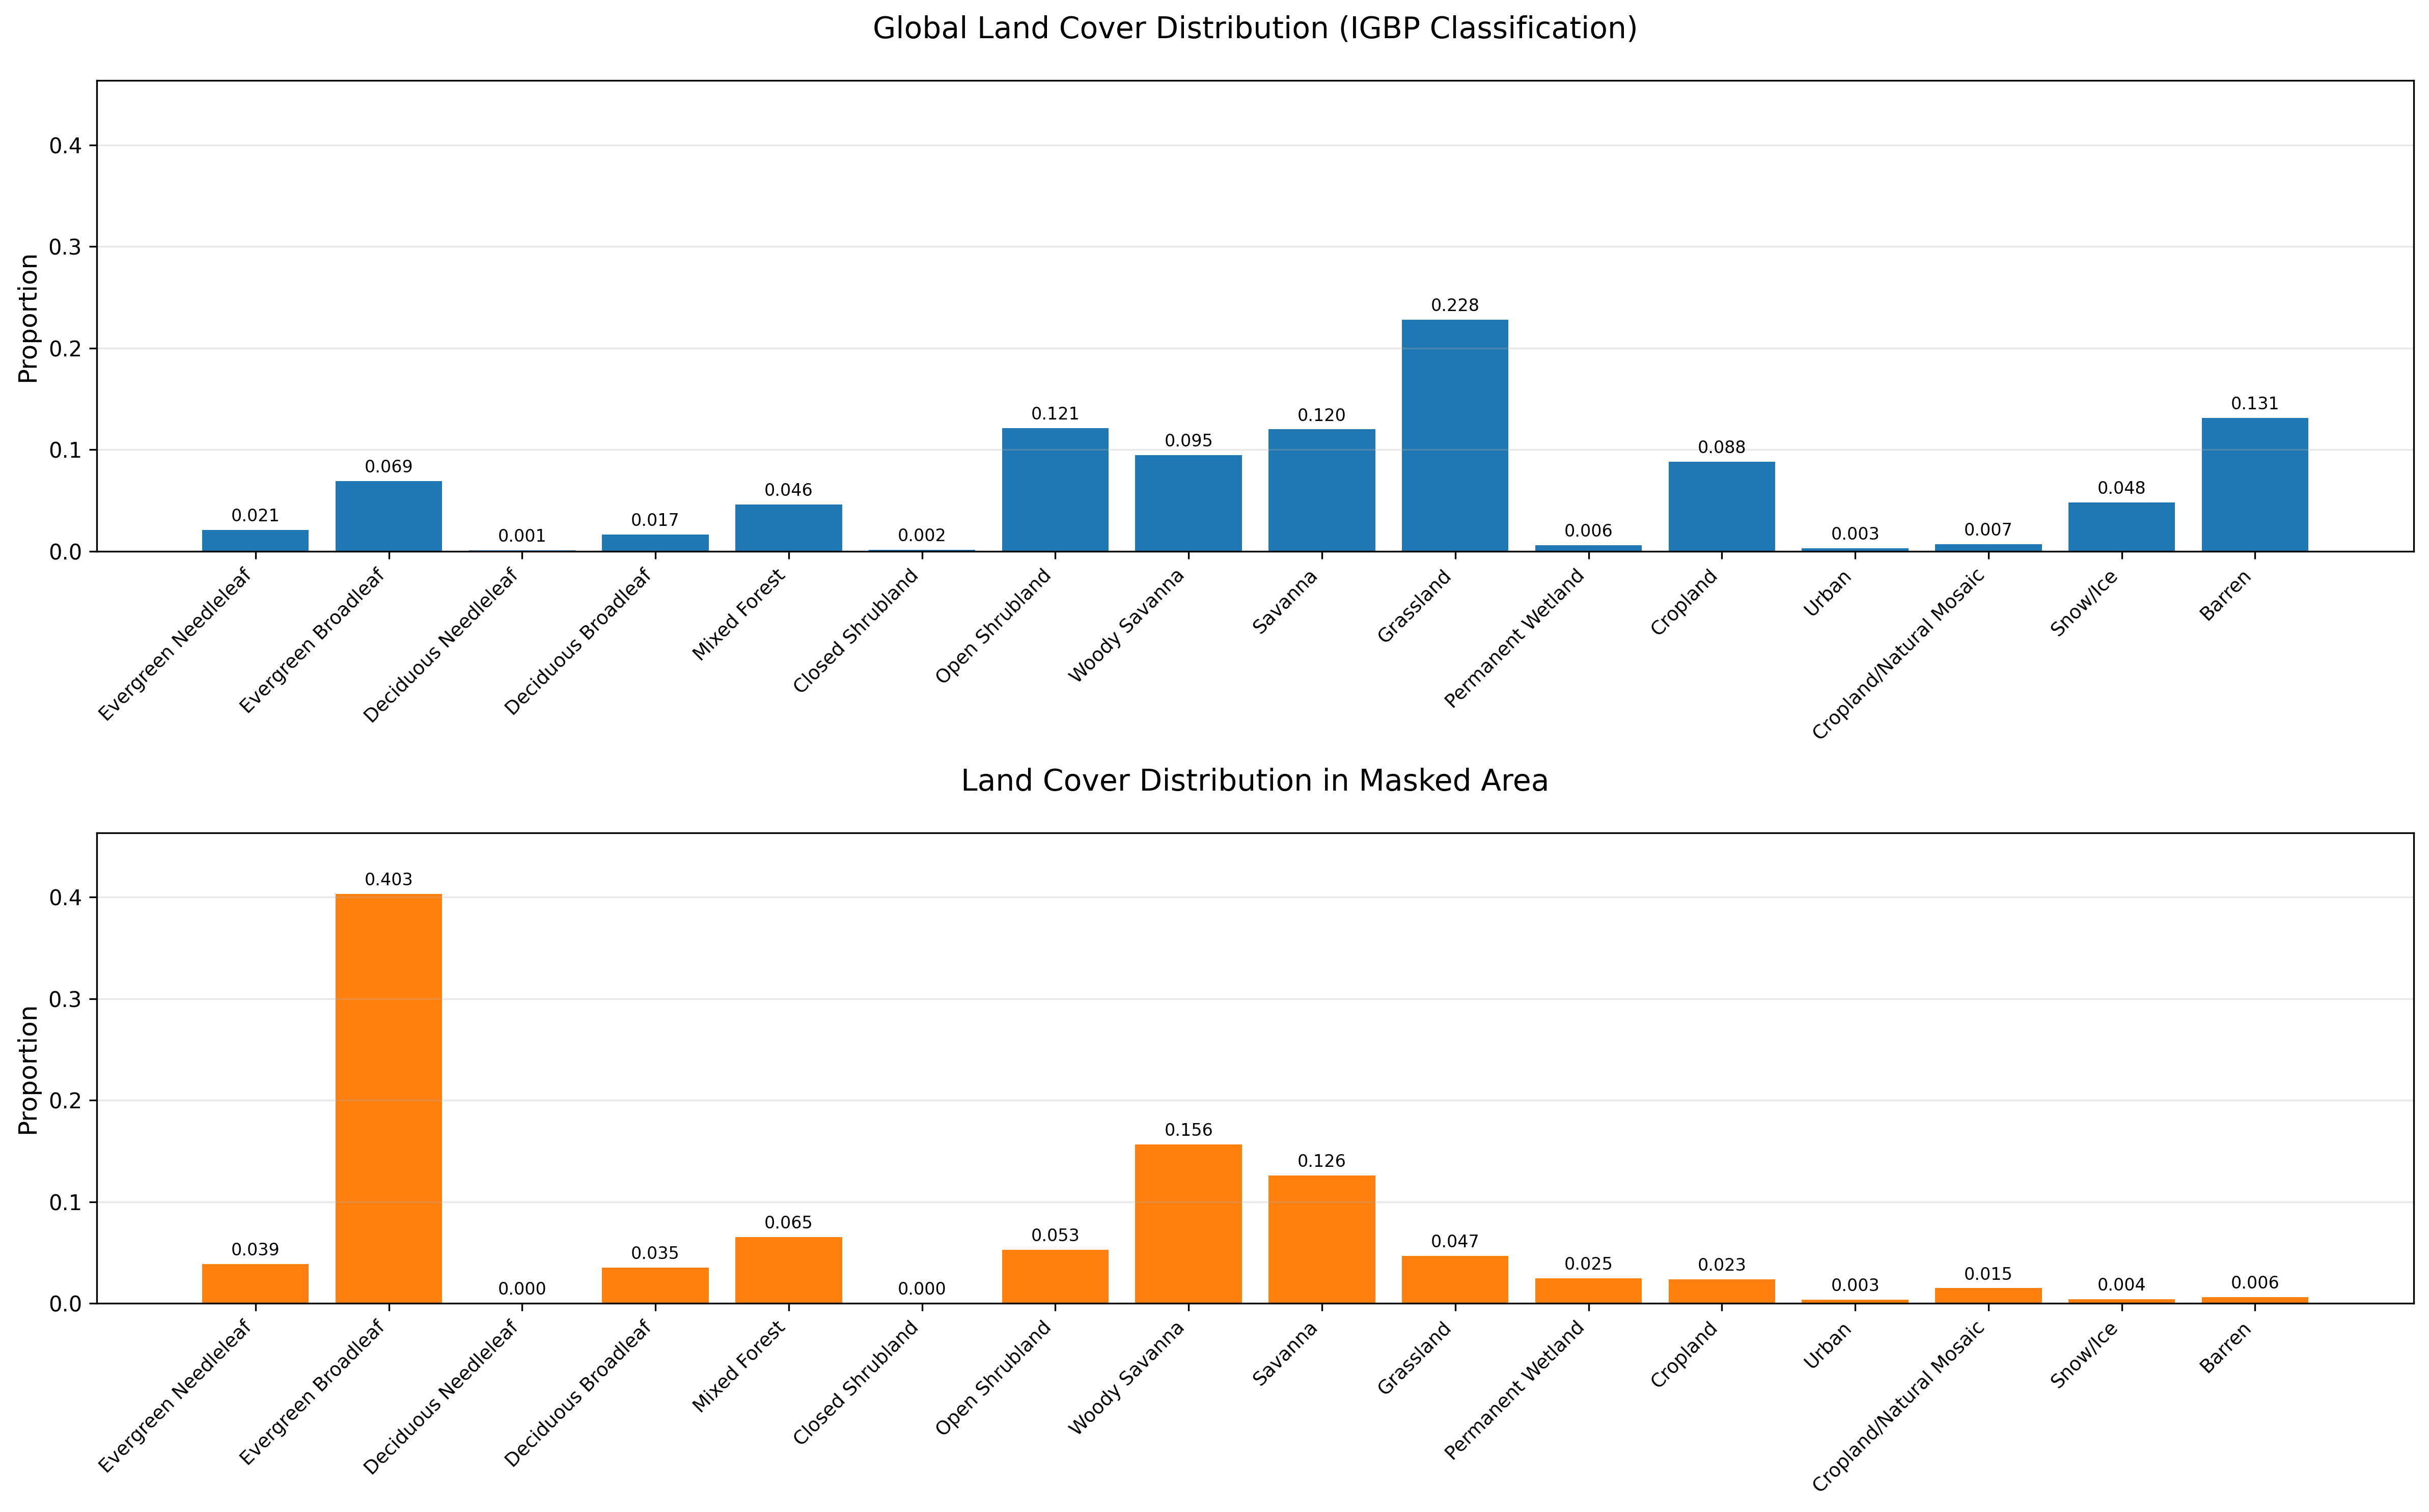

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. 加载数据
ds_lc = xr.open_dataset('/content/drive/My Drive/Science/landcover_2001-2024_yearly.nc')['landcover'][23]  # 地表覆盖数据
ds_mask_3 = xr.open_dataset('/content/drive/My Drive/Science/class_3.nc')['class']         # 掩膜数据
ds_mask_5 = xr.open_dataset('/content/drive/My Drive/Science/class_5.nc')['class']         # 掩膜数据

# 2. 计算全球比例
global_counts = np.bincount(ds_lc.values.ravel().astype(int), minlength=18)[1:17]
global_props = global_counts / global_counts.sum()

# 3. 计算掩膜内比例
#masked_lc = ds_lc.where((ds_mask_3 == 1) | (ds_mask_5 == 1))
masked_lc = ds_lc.where(ds_mask_3 == 1)
valid_data = masked_lc.values.ravel()
valid_data = valid_data[~np.isnan(valid_data)]  # 移除NaN
masked_counts = np.bincount(valid_data.astype(int), minlength=18)[1:17]
masked_props = masked_counts / masked_counts.sum()

# 4. 准备绘图数据
igbp_labels = [
    'Evergreen Needleleaf', 'Evergreen Broadleaf', 'Deciduous Needleleaf',
    'Deciduous Broadleaf', 'Mixed Forest', 'Closed Shrubland',
    'Open Shrubland', 'Woody Savanna', 'Savanna', 'Grassland',
    'Permanent Wetland', 'Cropland', 'Urban', 'Cropland/Natural Mosaic',
    'Snow/Ice', 'Barren'
]

df = pd.DataFrame({
    'IGBP Type': igbp_labels,
    'Global Proportion': global_props,
    'Masked Proportion': masked_props
})

# 5. 创建对比图像
plt.figure(figsize=(16, 10), dpi=300)

# 全球比例柱状图
plt.subplot(2, 1, 1)
bars_global = plt.bar(df['IGBP Type'], df['Global Proportion'], color='#1f77b4')
plt.title('Global Land Cover Distribution (IGBP Classification)', fontsize=14, pad=20)
plt.ylabel('Proportion', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, max(global_props.max(), masked_props.max()) * 1.15)

# 添加数值标签
for bar in bars_global:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 掩膜内比例柱状图
plt.subplot(2, 1, 2)
bars_masked = plt.bar(df['IGBP Type'], df['Masked Proportion'], color='#ff7f0e')
plt.title('Land Cover Distribution in Masked Area', fontsize=14, pad=20)
plt.ylabel('Proportion', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, max(global_props.max(), masked_props.max()) * 1.15)

# 添加数值标签
for bar in bars_masked:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 6. 保存和显示
plt.tight_layout()
#plt.savefig('landcover_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

# 7. 输出统计表格
#df['Global %'] = df['Global Proportion'] * 100
#df['Masked %'] = df['Masked Proportion'] * 100
#df[['IGBP Type', 'Global %', 'Masked %']].to_csv('landcover_stats.csv', index=False)
#print("对比图像已保存为 landcover_comparison.png")
#print("统计表格已保存为 landcover_stats.csv")

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
print(mpl.__version__)

!wget -O TimesNewRoman.ttf https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
font_dirs = ["/content/"]
font_files = fm.findSystemFonts(fontpaths=font_dirs, fontext='ttf')
for font_file in font_files:
    print(font_file) if 'TimesNewRoman' in font_file else None
    fm.fontManager.addfont(font_file)
plt.rcParams['font.serif'] = "Times New Roman"
plt.rcParams['font.family'] = "serif"

3.10.0
--2026-07-29 08:31:32--  https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
Resolving github.com (github.com)... 20.29.134.23
Connecting to github.com (github.com)|20.29.134.23|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/justrajdeep/fonts/master/Times%20New%20Roman.ttf [following]
--2026-07-29 08:31:32--  https://raw.githubusercontent.com/justrajdeep/fonts/master/Times%20New%20Roman.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 834452 (815K) [application/octet-stream]
Saving to: ‘TimesNewRoman.ttf’

TimesNewRoman.ttf   100%[===================>] 814.89K  --.-KB/s    in 0.03s   

2026-07-29 08:31:33 (23.6 MB/s) - ‘TimesNewRoman.ttf’ saved [834452/834452]

/c

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


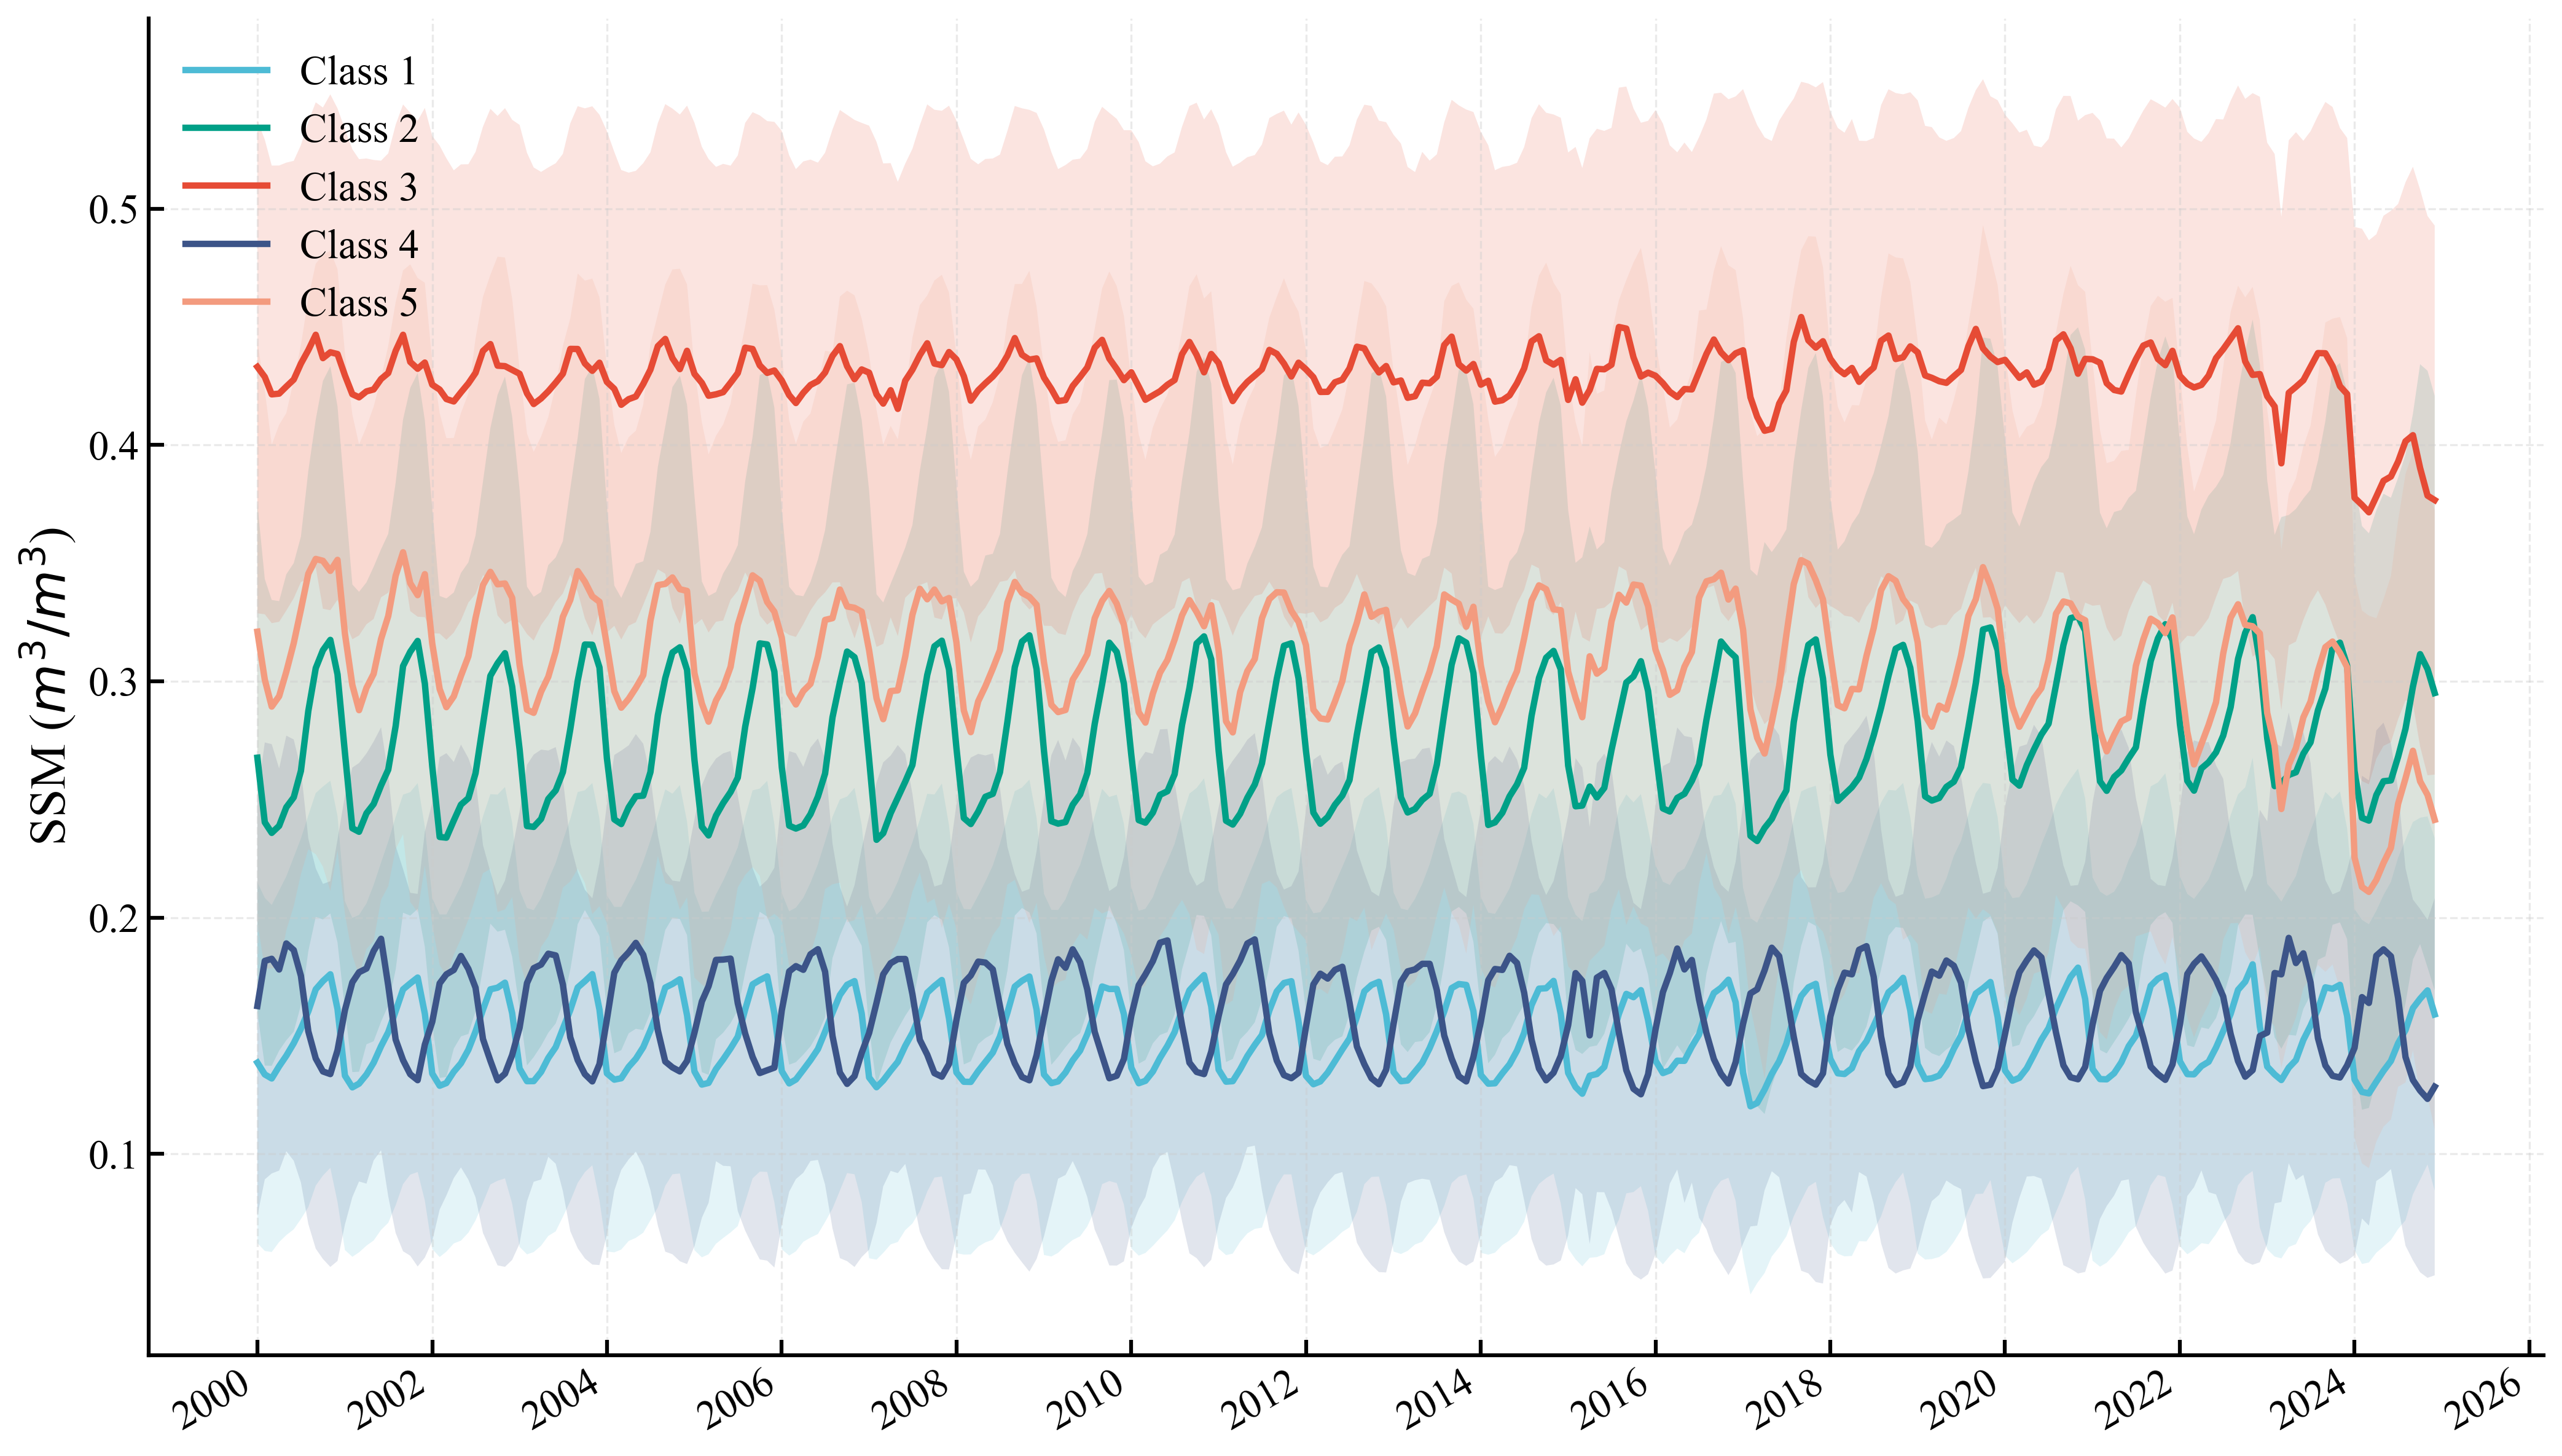

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates

# 1. 加载土壤湿度数据
soil_ds = xr.open_dataset('/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc')
soil_var = soil_ds['soil_moisture']  # 请替换为实际变量名

# 2. 改字体
plt.rcParams['font.serif'] = "Times New Roman"
plt.rcParams['font.family'] = "serif"
plt.rcParams['axes.labelsize'] = 20      # X、Y 轴标签字号
plt.rcParams['xtick.labelsize'] = 16     # X 轴刻度字号
plt.rcParams['ytick.labelsize'] = 16     # Y 轴刻度字号
plt.rcParams['legend.fontsize'] = 16     # 图例字号

# 3. 准备绘图
fig, ax = plt.subplots(figsize=(14, 8), dpi=300) # 将 dpi 设为 300 保证高清

# 4. 对应此前的 Nature NPG 5色聚类配色
colors = [
    '#4DBBD5',  # 天空蓝 (Sky Blue)
    '#00A087',  # 翡翠绿 (Teal/Green)
    '#E64B35',  # 经典朱红 (Red)
    '#3C5488',  # 经典深蓝 (Navy Blue)
    '#F39B7F'   # 浅橘/沙色 (Soft Orange)
]

# 5. 处理每个掩膜区域并绘图
for i in range(1, 6):
    # 加载掩膜
    mask_ds = xr.open_dataset(f'/content/drive/My Drive/Nature/class_{i}.nc')
    mask = mask_ds['class']  # 请替换为实际变量名

    # 应用掩膜计算区域平均值
    masked_soil = soil_var.where(mask == 1)  # 假设1表示有效区域
    monthly_mean = masked_soil.mean(dim=['y', 'x'])
    monthly_std = masked_soil.std(dim=['y', 'x'])

    # 绘制曲线 (加粗线宽以匹配大字号)
    ax.plot(monthly_mean.time, monthly_mean,
            label=f'Class {i}',
            color=colors[i-1],
            linewidth=2.5)

    # 绘制标准差阴影 (降低透明度使多条线叠加时更柔和)
    ax.fill_between(monthly_mean.time,
                     monthly_mean - monthly_std,
                     monthly_mean + monthly_std,
                     alpha=0.15,
                     color=colors[i-1],
                     edgecolor='none') # 去除阴影边缘线

# 6. 图表美化 (Nature Journal Style)

# 设置轴标签
ax.set_ylabel('SSM ($m^3/m^3$)', fontweight='normal')

# 去除右侧和上方的边框（顶刊标配，避免画面压抑）
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 调粗剩余的坐标轴线
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# 设置刻度线细节 (向内弯曲，调粗，加长)
ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.5)
ax.tick_params(axis='both', which='minor', direction='in', length=3.5, width=1.0)

# 优雅的虚线网格
ax.grid(True, linestyle='--', alpha=0.4, color='#cccccc')

# 现代极简图例 (去除边框，放置在最合适的位置)
ax.legend(frameon=False, loc='upper left')

# 设置时间轴格式
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.autofmt_xdate()

# 导出高质量图片
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Science/soil_moisture_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import STL  # 导入STL分解库
import pandas as pd

plt.rcParams['font.serif'] = "Times New Roman"
plt.rcParams['font.family'] = "serif"

# 1. 读取数据
soil_ds = xr.open_dataset("/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc")  # 土壤湿度数据
mask_ds = xr.open_dataset("/content/drive/My Drive/Science/class_3.nc")           # 掩膜数据

Ta_ds = xr.open_dataset("/content/drive/My Drive/Science/Ta_2000-2024_monthly.nc")  # 新增降水数据
Ts_ds = xr.open_dataset("/content/drive/My Drive/Science/Ts_2000-2024_monthly.nc")  # 新增蒸散发数据

# 2. 应用掩膜和空间范围限制
# 创建空间范围掩膜
spatial_mask = xr.DataArray(
    data=np.zeros_like(mask_ds['class']),
    dims=mask_ds['class'].dims,
    coords=mask_ds['class'].coords
)

# 设置y:300-400, x:300-600范围内的值为1
spatial_mask = spatial_mask.where(
    (spatial_mask.y < 50) | (spatial_mask.y > 150) |
    (spatial_mask.x < 700) | (spatial_mask.x > 1100),
    1
)

# 组合掩膜：原始掩膜 + 空间范围限制
combined_mask = (mask_ds['class'] == 1) & (spatial_mask == 1)

# 2. 应用掩膜
# 变量名称为 'soil_moisture' 和 'class'
masked_soil = soil_ds.soil_moisture.where(combined_mask)

masked_Ta = Ta_ds.Ta.where(combined_mask)
masked_Ts = Ts_ds.Ts.where(combined_mask)

# 3. 计算统计量
monthly_mean = masked_soil.mean(dim=["y", "x"])          # 每月平均值
monthly_std = masked_soil.std(dim=["y", "x"])            # 每月标准差

Ta_mean = masked_Ta.mean(dim=["y", "x"])
Ts_mean = masked_Ts.mean(dim=["y", "x"])

#####对降水数据进行STL分解
# 转换为pandas Series进行STL分解
Ts_series = pd.Series(Ts_mean, index=pd.to_datetime(monthly_mean.time))
# 执行STL分解（周期设为12个月）
stl = STL(Ts_series, period=12, robust=True)
result = stl.fit()
# 提取趋势分量
Ts_trend = result.trend

#输出土壤湿度数据
soil_2015_2024 = monthly_mean.sel(time=slice('2015-01-01', '2024-12-31'))
# 转换为DataFrame并打印
soil_df = soil_2015_2024.to_dataframe(name='Soil Moisture (%)')
csv_filename = "soil_moisture_2015-2024_NE.csv"
soil_df.to_csv(csv_filename, index=True)
print(f"2015-2024年土壤湿度数据已保存为: {csv_filename}")

# 4. 可视化
fig, ax1 = plt.subplots(figsize=(16, 7.5))

# 绘制平均值曲线
color1 = 'tab:red'
ax1.plot(monthly_mean.time, monthly_mean,
         'r-', linewidth=2, label="SSM")
# 添加标准差阴影
ax1.fill_between(monthly_mean.time,
                 monthly_mean - monthly_std,
                 monthly_mean + monthly_std,
                 color='red', alpha=0.2)
ax1.set_ylabel('Soil Moisture (%)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)

# 创建右Y轴（用于降水和蒸散发）
ax2 = ax1.twinx()
color2 = 'tab:blue'
color3 = 'tab:green'
color4 = 'tab:purple'  # 趋势线颜色
ax2.plot(monthly_mean.time, Ta_mean, color=color2, linestyle='--', label="Precipitation")
ax2.plot(monthly_mean.time, Ts_mean, color=color3, linestyle='-', label="Evapotranspiration")
# 绘制降水趋势线（粗线）
ax2.plot(monthly_mean.time, Ts_trend, color=color4, linewidth=3, linestyle='-', label="Precip Trend")
ax2.set_ylabel('Surface/Air Temperature (K)', fontsize=12)
ax2.tick_params(axis='y')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.1),
           ncol=4, framealpha=0.9, fontsize=11)

# 设置时间格式
ax1.xaxis.set_major_locator(mdates.YearLocator(2))  # 每2年一个刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.title("Hydrological Variables Time Series(2000-2024)", fontsize=14)
plt.grid(alpha=0.2, linestyle='--')
fig.tight_layout()


# 保存结果
plt.savefig("hydrological_variables_timeseries_Class5_CEE.png", dpi=300)
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


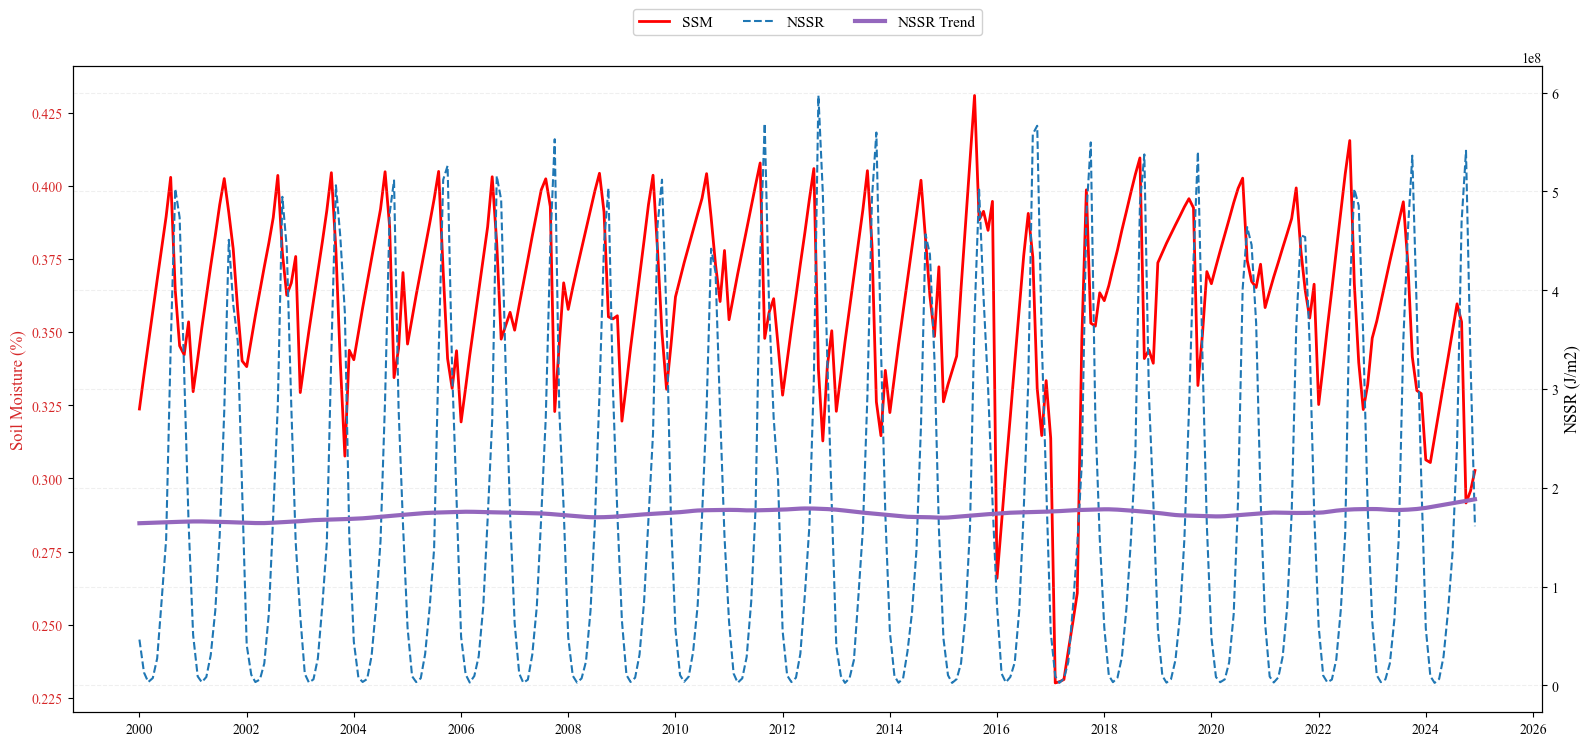

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import STL  # 导入STL分解库
import pandas as pd

plt.rcParams['font.serif'] = "Times New Roman"
plt.rcParams['font.family'] = "serif"

# 1. 读取数据
soil_ds = xr.open_dataset("/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc")  # 土壤湿度数据
mask_ds = xr.open_dataset("/content/drive/My Drive/Science/class_3.nc")           # 掩膜数据

NSSR_ds = xr.open_dataset("/content/drive/My Drive/Science/NSSR_2000-2024_monthly.nc")  # 新增降水数据


# 2. 应用掩膜和空间范围限制
# 创建空间范围掩膜
spatial_mask = xr.DataArray(
    data=np.zeros_like(mask_ds['class']),
    dims=mask_ds['class'].dims,
    coords=mask_ds['class'].coords
)

# 设置y:300-400, x:300-600范围内的值为1
spatial_mask = spatial_mask.where(
    (spatial_mask.y < 50) | (spatial_mask.y > 100) |
    (spatial_mask.x < 980) | (spatial_mask.x > 1100),
    1
)

# 组合掩膜：原始掩膜 + 空间范围限制
combined_mask = (mask_ds['class'] == 1) & (spatial_mask == 1)

# 2. 应用掩膜
# 变量名称为 'soil_moisture' 和 'class'
masked_soil = soil_ds.soil_moisture.where(combined_mask)

masked_NSSR = NSSR_ds.NSSR.where(combined_mask)

# 3. 计算统计量
monthly_mean = masked_soil.mean(dim=["y", "x"])          # 每月平均值

NSSR_mean = masked_NSSR.mean(dim=["y", "x"])

#####对降水数据进行STL分解
# 转换为pandas Series进行STL分解
NSSR_series = pd.Series(NSSR_mean, index=pd.to_datetime(monthly_mean.time))
# 执行STL分解（周期设为12个月）
stl = STL(NSSR_series, period=12, robust=True)
result = stl.fit()
# 提取趋势分量
NSSR_trend = result.trend

# 4. 可视化
fig, ax1 = plt.subplots(figsize=(16, 7.5))

# 绘制平均值曲线
color1 = 'tab:red'
ax1.plot(monthly_mean.time, monthly_mean,
         'r-', linewidth=2, label="SSM")
ax1.set_ylabel('Soil Moisture (%)', color=color1, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color1)

# 创建右Y轴（用于降水和蒸散发）
ax2 = ax1.twinx()
color2 = 'tab:blue'
color4 = 'tab:purple'  # 趋势线颜色
ax2.plot(monthly_mean.time, NSSR_mean, color=color2, linestyle='--', label="NSSR")
# 绘制降水趋势线（粗线）
ax2.plot(monthly_mean.time, NSSR_trend, color=color4, linewidth=3, linestyle='-', label="NSSR Trend")
ax2.set_ylabel('NSSR (J/m2)', fontsize=12)
ax2.tick_params(axis='y')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.1),
           ncol=4, framealpha=0.9, fontsize=11)

# 设置时间格式
ax1.xaxis.set_major_locator(mdates.YearLocator(2))  # 每2年一个刻度
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(alpha=0.2, linestyle='--')
fig.tight_layout()


# 保存结果
#plt.savefig("hydrological_variables_timeseries_Class5_CEE.png", dpi=300)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# 1. 读取数据
soil_ds = xr.open_dataset("/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc")  # 土壤湿度数据
mask_ds = xr.open_dataset("/content/drive/My Drive/Science/class_3.nc")           # 掩膜数据

P_ds = xr.open_dataset("/content/drive/My Drive/Science/P_2000-2024_monthly.nc")  # 新增降水数据
Ts_ds = xr.open_dataset("/content/drive/My Drive/Science/Ts_2000-2024_monthly.nc")  # 新增蒸散发数据

# 2. 应用掩膜和空间范围限制
# 创建空间范围掩膜
spatial_mask = xr.DataArray(
    data=np.zeros_like(mask_ds['class']),
    dims=mask_ds['class'].dims,
    coords=mask_ds['class'].coords
)

# 设置y:300-400, x:300-600范围内的值为1
spatial_mask = spatial_mask.where(
    (spatial_mask.y < 300) | (spatial_mask.y > 400) |
    (spatial_mask.x < 300) | (spatial_mask.x > 600),
    1
)

# 组合掩膜：原始掩膜 + 空间范围限制
combined_mask = (mask_ds['class'] == 1) & (spatial_mask == 1)

# 2. 应用掩膜
# 变量名称为 'soil_moisture' 和 'class'
masked_soil = soil_ds.soil_moisture.where(combined_mask)

masked_P = P_ds.P.where(combined_mask)
masked_Ts = Ts_ds.Ts.where(combined_mask)

# 3. 计算统计量
monthly_mean = masked_soil.mean(dim=["y", "x"])          # 每月平均值
P_mean = masked_P.mean(dim=["y", "x"])
Ts_mean = masked_Ts.mean(dim=["y", "x"])

valid_points = np.argwhere(~np.isnan(masked_soil.isel(time=0).values))
y_idx, x_idx = valid_points[1500]  # 取第一个有效点
single_soil = masked_soil.isel(y=y_idx, x=x_idx)
single_P = masked_P.isel(y=y_idx, x=x_idx)
single_Ts = masked_Ts.isel(y=y_idx, x=x_idx)

# 4. 可视化
fig, ax1 = plt.subplots(figsize=(16, 8))

# 绘制平均值曲线
# 1. 土壤湿度曲线 (左Y轴)
ax1.plot(monthly_mean.time, single_soil,
         color='#E63946',  # 深红色
         linewidth=2.5,
         linestyle='-',
         marker='o',       # 圆形标记
         markersize=4,
         markevery=12,     # 每年标记一个点
         alpha=0.9,
         label="Soil Moisture")

# 设置左轴样式
ax1.set_ylabel('Soil Moisture (%)', fontsize=12, color='#E63946')
ax1.tick_params(axis='y', labelcolor='#E63946')
ax1.grid(alpha=0.1, linestyle='--')

# 2. 降水曲线 (右内Y轴)
ax2 = ax1.twinx()
ax2.plot(monthly_mean.time, single_P,
         color='tab:blue',  # 深蓝色
         linewidth=2.0,
         linestyle='-',    # 点线
         marker='',
         alpha=1.0,
         zorder=5,
         label="Precipitation")

# 设置右内轴样式
ax2.set_ylabel('Precipitation (mm)', fontsize=12, color='#1D3557')
ax2.tick_params(axis='y', labelcolor='#1D3557')

# 3. 温度曲线 (右外Y轴)
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.12))  # 外移12%
ax3.plot(monthly_mean.time, single_Ts,
         color='#2A9D8F',  # 蓝绿色
         linewidth=2.2,
         linestyle='-.',   # 点划线
         marker='s',       # 方形标记
         markersize=4,
         markevery=8,      # 每8个月标记一个点
         alpha=0.9,
         label="Surface Temperature")

# 设置右外轴样式
ax3.set_ylabel('Temperature (K)', fontsize=12, color='#2A9D8F')
ax3.tick_params(axis='y', labelcolor='#2A9D8F')

# 4. 高级图例设计
handles, labels = [], []
for ax in [ax1, ax2, ax3]:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

# 创建分类图例
legend = ax1.legend(handles, labels,
                   loc='upper center',
                   bbox_to_anchor=(0.5, 1.2),
                   ncol=3,
                   frameon=True,
                   framealpha=0.95,
                   edgecolor='#F1FAEE',
                   fontsize=11,
                   title='Climate Variables',
                   title_fontsize=12)

# 设置图例背景色
legend.get_frame().set_facecolor('#A8DADC')

# 5. 整体美化
plt.title("Variables Time Series (2000-2024)",
          fontsize=15, pad=20, fontweight='bold')
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_minor_locator(mdates.YearLocator(1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 添加网格和背景
ax1.set_facecolor('#F1FAEE')  # 浅背景色
fig.patch.set_facecolor('#FFFFFF')  # 白色背景

# 调整布局
fig.tight_layout()
plt.subplots_adjust(top=0.88, right=0.82, bottom=0.12)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import pandas as pd
import numpy as np
from tqdm import tqdm

# 1. 加载掩膜文件
mask_ds = xr.open_dataset('/content/drive/My Drive/Science/class_3.nc')

# 2. 获取掩膜为1的坐标位置
spatial_mask = xr.DataArray(
    data=np.zeros_like(mask_ds['class']),
    dims=mask_ds['class'].dims,
    coords=mask_ds['class'].coords
)
# 设置y:300-400, x:300-600范围内的值为1
spatial_mask = spatial_mask.where(
    (spatial_mask.y < 300) | (spatial_mask.y > 400) |
    (spatial_mask.x < 700) | (spatial_mask.x > 900),
    1
)
# 组合掩膜：原始掩膜 + 空间范围限制
combined_mask = (mask_ds['class'] == 1) & (spatial_mask == 1)

valid_coords = np.where(combined_mask)
y_indices, x_indices = valid_coords[0], valid_coords[1]
print(f"找到{len(y_indices)}个有效空间位置")
coords = list(zip(y_indices, x_indices))

# 3. 加载土壤湿度数据（标签）
soil_ds = xr.open_dataset('/content/drive/My Drive/Science/dmv_2000-2024_monthly.nc')
soil_var = soil_ds['dmv']  # 替换为实际变量名

# 4. 加载特征数据
dynamic_ds = []                                # 动态变量文件列表
dynamic_files = ['/content/drive/My Drive/Science/P_2000-2024_monthly.nc',
          '/content/drive/My Drive/Science/snow_2000-2024_monthly.nc',
          '/content/drive/My Drive/Science/NSSR_2000-2024_monthly.nc',
          '/content/drive/My Drive/Science/Ts_2000-2024_monthly.nc',
          '/content/drive/My Drive/Science/Ta_2000-2024_monthly.nc',
          '/content/drive/My Drive/Science/wind_2000-2024_monthly.nc',
          '/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc',
          ]  # 替换为实际文件名

for f in dynamic_files:
    dynamic_ds.append(xr.open_dataset(f))
# 加载静态特征数据
soil_texture_ds = xr.open_dataset('/content/drive/My Drive/Science/soil.nc')

data_records = []
# 6. 设定时间点（从2000-1至2021-12）
for i in range(21):
  for time_idx in range (i*12+12,i*12+17):
# 获取当前时间步所有有效位置的特征值
    features = []
    label_vals = []

    for y, x in tqdm(coords,desc="提取标签"):
        label_vals.append(soil_var[time_idx, y, x].item())

#添加动态变量
    for ds in tqdm(dynamic_ds, desc="处理动态变量"):
        var_name = list(ds.data_vars)[0]  # 获取第一个变量名
        for y, x in coords:
            features.append(ds[var_name][time_idx, y, x].item())

    for t in tqdm(range(soil_texture_ds.dims['type']), desc="处理静态变量"):  # 遍历所有土壤类型
        for y, x in coords:
            features.append(soil_texture_ds['soil'][t, y, x].item()/100)

    num_samples = len(coords)
    num_dynamic = 7
    num_static = 3

# 转换为特征矩阵 (样本数 × 特征数)
    feature_matrix = np.array(features).reshape(num_dynamic + num_static , num_samples).T
    label_vector = np.array(label_vals)
    data_records.append(np.hstack((feature_matrix, label_vector.reshape(-1,1))))

#特征排序P，snow，NSSR,Ts,Ta,wind,SSM，sand，clay，bulk,dmv

result = np.vstack(data_records)
# 11. 创建最终数据集
full_df = pd.DataFrame(result)
# 12. 统一处理空值（删除任何列含空值的行）
final_df = full_df.dropna()

# 统计信息
valid_samples = len(final_df)
print(f"有效样本数: {valid_samples}")

# 12. 保存结果（只包含标签和特征）
final_df.to_csv('/content/drive/My Drive/Science/training_dataset_CA_down.csv', index=False)
print(f"数据集已保存")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as tf
from torch.utils import data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import pylab
from tqdm import tqdm

from google.colab import drive
drive.mount('/content/drive')

## 读取CSV文件
data_read = pd.read_csv('/content/drive/My Drive/Science/training_dataset_CA_down.csv')

# 2️分离标签（假设最后一列为标签）
labels = data_read.iloc[:, -1].values
y = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

# 3️为每个特征创建独立张量
feature_tensors = {}
for col in data_read.columns[:-1]:  # 遍历除标签外的所有列
    # 提取单列特征并转换为1D张量
    feature_values = data_read[col].values
    feature_tensor = torch.tensor(feature_values, dtype=torch.float32).unsqueeze(1)  # 升维为[N,1]
    # 存储到字典（按特征名索引）
    feature_tensors[col] = feature_tensor
#特征排序P，snow,NSSR,Ts,Ta,wind,SSM，sand，clay，bulk
P=feature_tensors['0']; snow=feature_tensors['1']; NSSR=feature_tensors['2']
Ts=feature_tensors['3']; Ta=feature_tensors['4']; wind=feature_tensors['5']
SSM=feature_tensors['6'];sand=feature_tensors['7']; clay=feature_tensors['8']; bulk=feature_tensors['9']

P_snow=P+snow
water_input = torch.cat([sand, clay, bulk, SSM, P_snow], dim=1)
EV_input = torch.cat([NSSR, Ts, Ta, SSM, wind], dim=1)

##构建模型
class Net(nn.Module):
    def __init__(self, input_size, output_size):
        super(Net, self).__init__()
        self.bn = nn.BatchNorm1d(input_size)
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32,16)
        self.fc3 = nn.Linear(16,8)
        self.fc4 = nn.Linear(8,output_size)

    def forward(self,x):
        x = self.bn(x)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = torch.tanh(self.fc3(x))
        x = self.fc4(x)
        return x

def load_array(data_arrays, batch_size, is_train=True):
    dataset = data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset,batch_size,shuffle=True)

#微分水平衡模型
def Water(P, M, EV, Inf):
    output = P+M-EV-Inf
    return output

#散点图
def scatter_plot_frequency(x, y):
  xy = np.vstack([x,y])
  z = gaussian_kde(xy)(xy)
  # Sort the points by density, so that the densest points are plotted last
  idx = z.argsort()
  x, y, z = x[idx], y[idx], z[idx]
  fig, ax = plt.subplots()
  # 设置参考的1：1虚线参数
  xxx = [-0.5, 0.5]
  yyy = [-0.5, 0.5]
  plt.plot(xxx, yyy, c='0', linewidth=1, linestyle=':', marker='.', alpha=0.3)  # 绘制虚线
  plt.scatter(x, y, c=z, s=20, cmap='Spectral_r')
  z=np.polyfit(x,y,1)
  p=np.poly1d(z)
  pylab.plot(x,p(x),"r")
  plt.colorbar()
  plt.show()

class ConstrainedLoss(nn.Module):
    def __init__(self, base_loss, penalty_weight):
        super().__init__()
        self.base_loss = base_loss  # 如nn.MSELoss()
        self.penalty_weight = penalty_weight

    def forward(self, outputs, targets):
        base_loss = self.base_loss(outputs, targets)

        # 计算超出[-1,1]范围的惩罚项
        lower_penalty = torch.relu(-0.2 - outputs).sum()  # 小于-0.5的惩罚
        upper_penalty = torch.relu(outputs - 0.2).sum()   # 大于0.5的惩罚
        constraint_loss = lower_penalty + upper_penalty

        return base_loss + self.penalty_weight * constraint_loss

#模型训练
batch_size = 128 #128
num_epochs = 2000  #2000
data_iter = load_array((P,snow,EV_input,water_input,y), batch_size)

model_water = Net(5,1)
model_ev = Net(5,1)
#criterion = ConstrainedLoss(nn.HuberLoss(delta=0.01), penalty_weight=1)
criterion = nn.HuberLoss(delta=0.01)
#trainer = torch.optim.SGD(model_water.parameters(),lr=0.001)
trainer1 = torch.optim.AdamW(model_water.parameters(), lr=1e-3, weight_decay=1e-5)
trainer2 = torch.optim.AdamW(model_ev.parameters(), lr=1e-3, weight_decay=1e-5)

for epoch in tqdm(range(num_epochs),desc="模型训练"):
    for p1,sn,ev1,wa,y1 in data_iter:
        inf = model_water(wa)
        ev = model_ev(ev1)
        output = Water(p1,sn,ev,inf)/0.07
        loss = criterion(output, y1)

        trainer1.zero_grad()
        trainer2.zero_grad()
        loss.backward()
        trainer1.step()
        trainer2.step()

#模型保存
torch.save(model_water.state_dict(), str('/content/drive/My Drive/Science/model_water_CA_down.pth'))
torch.save(model_ev.state_dict(), str('/content/drive/My Drive/Science/model_ev_CA_down.pth'))

#模型测试
Inf_test = model_water(water_input)
EV_test = model_ev(EV_input)
output_test = Water(P, snow, EV_test, Inf_test)/0.07
loss = criterion(output_test, y)
print(loss)


#模型输出评估
#"""
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

Y_test = y.numpy()
Y_pred = output_test.detach().numpy()
indices = np.where(Y_pred > 0.4)[0]
print(indices)
r2 = r2_score(Y_test, Y_pred)
ResidualSquare = (Y_pred - Y_test) ** 2
MSE = np.mean(ResidualSquare)
bias = np.mean(Y_pred - Y_test)
RMSE = np.sqrt(MSE)
ubRMSE = np.sqrt(RMSE ** 2 - bias ** 2)
print(f'R2={r2}')
print(f'bias={bias}')
print(f'RMSE={RMSE}')
print(f'ubRMSE={ubRMSE}')
print("R P", pearsonr(Y_pred[:,0], Y_test[:,0]))
scatter_plot_frequency(Y_test[:,0],Y_pred[:,0])  #生成散点图
#"""


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


  0%|          | 0/15000 [00:00<?, ?it/s]

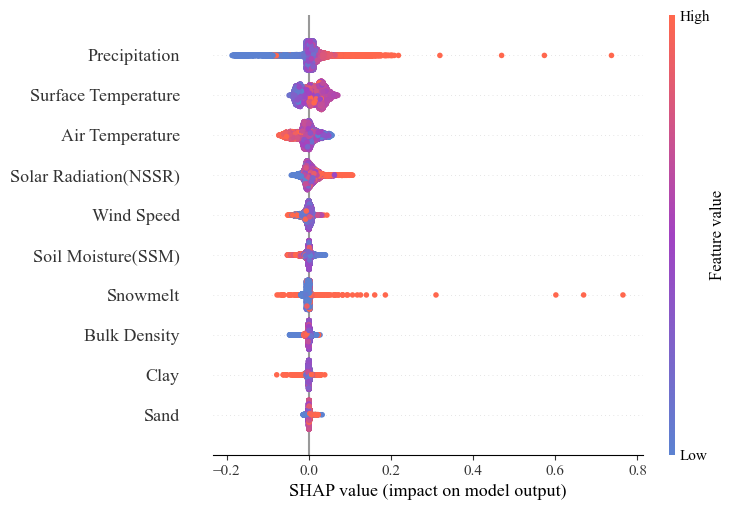

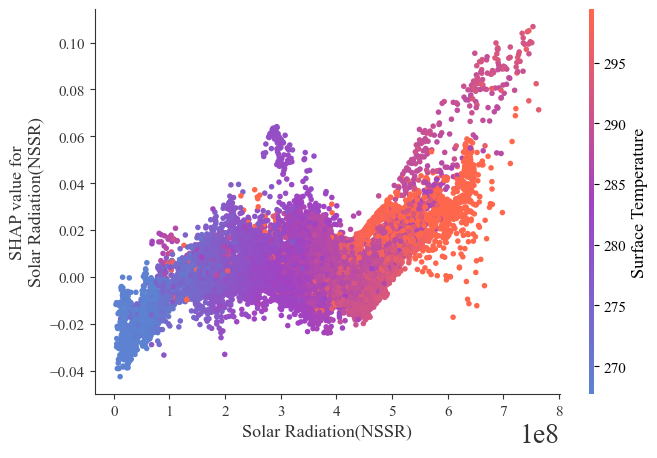

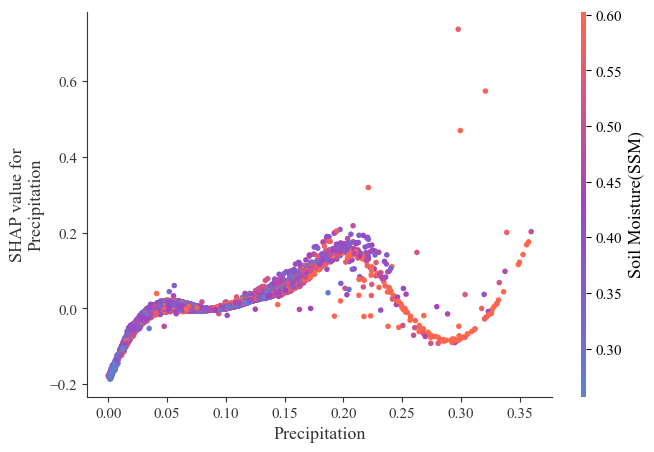

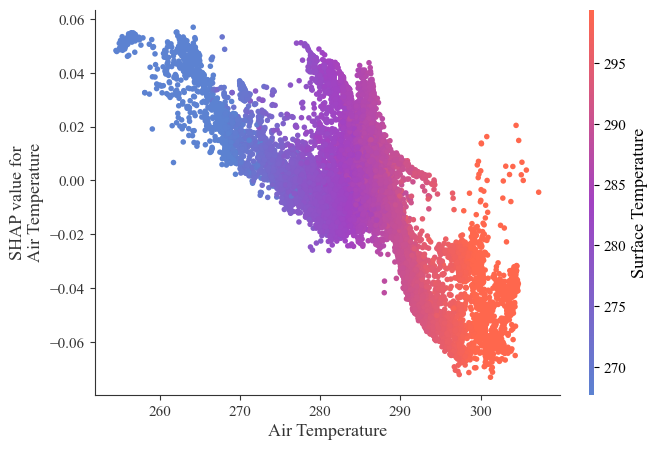

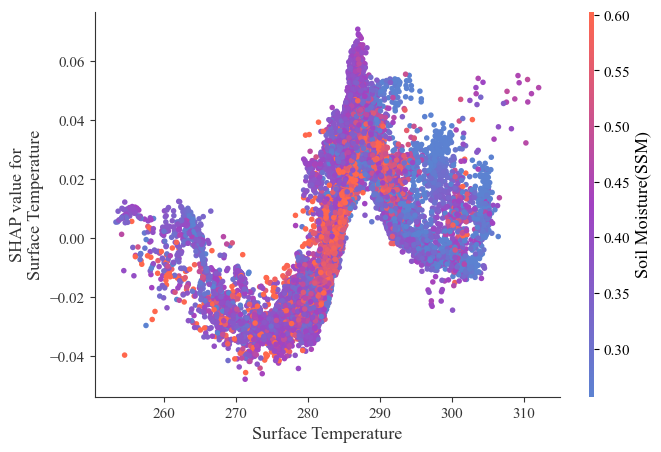

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as tf
import pandas as pd
import numpy as np
import shap
import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors # Import mcolors for LinearSegmentedColormap
from google.colab import drive
drive.mount('/content/drive')

## 读取CSV文件
data_read = pd.read_csv('/content/drive/My Drive/Science/training_dataset_ENA_down_test1.csv')

# 分离标签（最后一列为标签）
labels = data_read.iloc[:, -1].values
y = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

# 3为每个特征创建独立张量
feature_tensors = {}
for col in data_read.columns[:-1]:  # 遍历除标签外的所有列
    # 提取单列特征并转换为1D张量
    feature_values = data_read[col].values
    feature_tensor = torch.tensor(feature_values, dtype=torch.float32).unsqueeze(1)
    # 存储到字典（按特征名索引）
    feature_tensors[col] = feature_tensor
#特征排序P，snow,NSSR,Ts,Ta,wind,SSM，sand，clay，bulk
# 提取所有特征数据（按原始顺序）
features = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
X = torch.cat([feature_tensors[col] for col in features], dim=1)

# 创建特征名称列表（对应SHAP分析）
feature_names = ['Precipitation', 'Snowmelt', 'Solar Radiation(NSSR)', 'Surface Temperature', 'Air Temperature',
                'Wind Speed', 'Soil Moisture(SSM)', 'Sand', 'Clay', 'Bulk Density']

##构建模型
class Net(nn.Module):
    def __init__(self, input_size, output_size):
        super(Net, self).__init__()
        self.bn = nn.BatchNorm1d(input_size)
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32,16)
        self.fc3 = nn.Linear(16,8)
        self.fc4 = nn.Linear(8,output_size)

    def forward(self,x):
        x = self.bn(x)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = torch.tanh(self.fc3(x))
        x = self.fc4(x)
        return x

model_water = Net(5,1)
model_ev = Net(5,1)
model_water.load_state_dict(torch.load(str('/content/drive/My Drive/Science/model_water_ENA_down.pth')))
model_ev.load_state_dict(torch.load(str('/content/drive/My Drive/Science/model_ev_ENA_down.pth')))
model_water.eval();model_ev.eval()

####构建可解释的包装模型####
class WrapperModel(nn.Module):
    def __init__(self, water_model, ev_model):
        super().__init__()
        self.water_model = water_model
        self.ev_model = ev_model

    def forward(self, x):
        # 分离各特征 [P, M, NSSR, Ts, Ta, wind, SSM, sand, clay, bulk]
        P = x[:, 0:1]
        snow = x[:, 1:2]
        NSSR = x[:, 2:3]
        Ts = x[:, 3:4]
        Ta = x[:, 4:5]
        wind = x[:, 5:6]
        SSM = x[:, 6:7]
        sand = x[:, 7:8]
        clay = x[:, 8:9]
        bulk = x[:, 9:10]

        # 重构模型输入
        P_snow = P + snow
        water_input = torch.cat([sand, clay, bulk, SSM, P_snow], dim=1)
        EV_input = torch.cat([NSSR, Ts, Ta, SSM, wind], dim=1)
        # 模型预测
        Inf = self.water_model(water_input)
        EV = self.ev_model(EV_input)
        # 计算最终输出 (土壤湿度变化)
        return (P + snow - EV - Inf)/0.07
    def predict(self, x):
        with torch.no_grad():
              # 转换为tensor并执行前向传播
              x_tensor = torch.tensor(x, dtype=torch.float32)
              outputs = self.forward(x_tensor)
              return outputs.numpy()

# 创建包装模型
wrapper = WrapperModel(model_water,model_ev)
wrapper.eval()

#########SHAP分析实现########
# 创建背景数据集（使用KMeans聚类减少计算量）
background_data = shap.kmeans(X.numpy(), 50)  # 50个聚类中心作为背景

# 创建SHAP解释器
explainer = shap.KernelExplainer(
    model=wrapper.predict,
    data=background_data
)

# 计算SHAP值（使用10000个样本）
shap_values = explainer.shap_values(X[:15000].numpy())
shap_values_2d = np.squeeze(shap_values, axis=-1)

###保存为HDF格式
#with h5py.File('/content/drive/My Drive/Nature/SHAP/shap_data.h5', 'w') as f:
#    f.create_dataset('shap_values', data=shap_values_2d)
#    f.create_dataset('X_sample', data=X.numpy())
#    f.create_dataset('feature_names', data=np.bytes_(feature_names))

# 可视化分析

#cmap="?"配色viridis Spectral coolwar mRdYlGn RdYlBu RdBu RdGy PuOr BrBG PiYG
#字体设计
plt.rcParams['font.size'] = 20
plt.rcParams['font.serif'] = "Times New Roman"
plt.rcParams['font.family'] = "serif"

# 定义自定义色带
colors = ["#5C82D1",  "#A242C2",  "#FF674D"]   # 蓝色 (低) -> 指定中间色 (中) -> 红色 (高)
my_cmap = mcolors.LinearSegmentedColormap.from_list(
    "my_palette",
    colors
)

shap.summary_plot(
    shap_values_2d,
    X[:15000].numpy(),
    feature_names,
    plot_type="dot",
    cmap=my_cmap
#    show=False
)
#plt.savefig('shap_summary.png', dpi=300)


# 详细依赖关系分析
shap.dependence_plot(
    "Solar Radiation(NSSR)",
    shap_values_2d,
    X[:15000].numpy(),
    feature_names=feature_names,
    interaction_index="Surface Temperature",
    cmap=my_cmap
)

shap.dependence_plot(
    "Precipitation",
    shap_values_2d,
    X[:15000].numpy(),
    feature_names=feature_names,
    interaction_index="Soil Moisture(SSM)",
    cmap=my_cmap
)

shap.dependence_plot(
    "Air Temperature",
    shap_values_2d,
    X[:15000].numpy(),
    feature_names=feature_names,
    interaction_index="Surface Temperature",
    cmap=my_cmap
)

shap.dependence_plot(
    "Surface Temperature",
    shap_values_2d,
    X[:15000].numpy(),
    feature_names=feature_names,
    interaction_index="Soil Moisture(SSM)",
    cmap=my_cmap
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


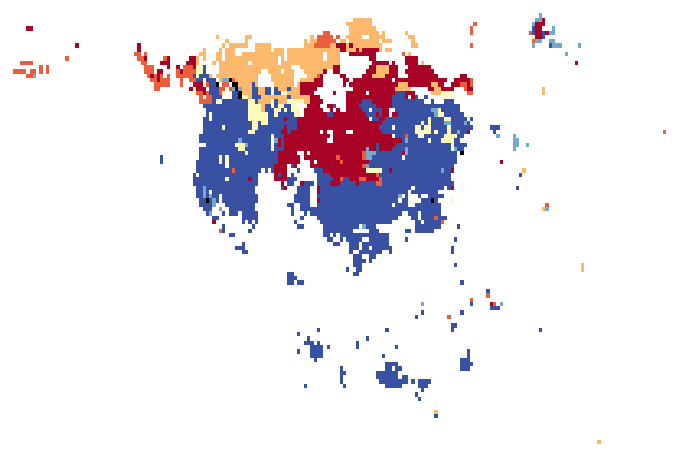

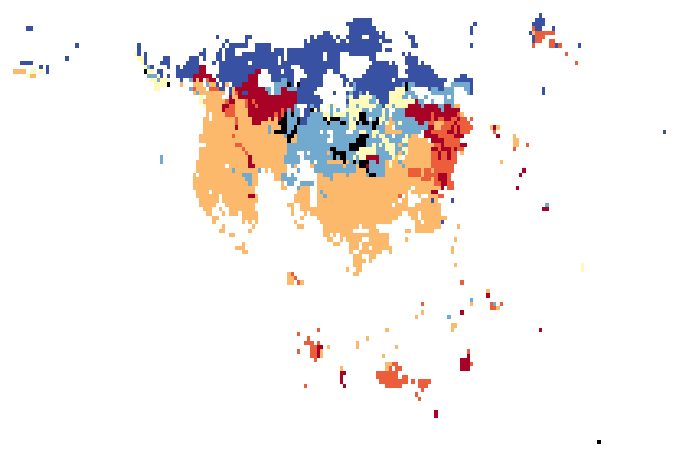

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import pandas as pd
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as tf
import shap
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1. 加载掩膜文件
mask_ds = xr.open_dataset('/content/drive/My Drive/Science/class_3.nc')

# 2. 获取掩膜为1的坐标位置
spatial_mask = xr.DataArray(
    data=np.zeros_like(mask_ds['class']),
    dims=mask_ds['class'].dims,
    coords=mask_ds['class'].coords
)
# 设置y:300-400, x:300-600范围内的值为1
spatial_mask = spatial_mask.where(
    (spatial_mask.y < 300) | (spatial_mask.y > 400) |
    (spatial_mask.x < 700) | (spatial_mask.x > 900),
    1
)
# 组合掩膜：原始掩膜 + 空间范围限制
combined_mask = (mask_ds['class'] == 1) & (spatial_mask == 1)

valid_coords = np.where(combined_mask)
y_indices, x_indices = valid_coords[0], valid_coords[1]
print(f"找到{len(y_indices)}个有效空间位置")
coords = list(zip(y_indices, x_indices))

# 4. 加载特征数据
dynamic_ds = []                                # 动态变量文件列表
dynamic_files = ['/content/drive/My Drive/Science/P_2000-2024_monthly.nc',
          '/content/drive/My Drive/Science/snow_2000-2024_monthly.nc',
          '/content/drive/My Drive/Science/NSSR_2000-2024_monthly.nc',
          '/content/drive/My Drive/Science/Ts_2000-2024_monthly.nc',
          '/content/drive/My Drive/Science/Ta_2000-2024_monthly.nc',
          '/content/drive/My Drive/Science/wind_2000-2024_monthly.nc',
          '/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc',
          ]  # 替换为实际文件名

for f in dynamic_files:
    dynamic_ds.append(xr.open_dataset(f))
# 加载静态特征数据
soil_texture_ds = xr.open_dataset('/content/drive/My Drive/Science/soil.nc')

data_records = []
# 6. 设定时间点（从2000-1至2024-12共300组数据，下降期选10-13，上升期选3-6）
time_idx = (2023 - 2000) * 12 + 2  # 2024年2月索引=284
# 获取当前时间步所有有效位置的特征值
features = []
label_vals = []
#添加动态变量
for ds in tqdm(dynamic_ds, desc="处理动态变量"):
    var_name = list(ds.data_vars)[0]  # 获取第一个变量名
    for y, x in coords:
        features.append(ds[var_name][time_idx, y, x].item())

for t in tqdm(range(soil_texture_ds.dims['type']), desc="处理静态变量"):  # 遍历所有土壤类型
    for y, x in coords:
        features.append(soil_texture_ds['soil'][t, y, x].item()/100)

num_samples = len(coords)
num_dynamic = 7
num_static = 3
# 转换为特征矩阵 (样本数 × 特征数)
feature_matrix = np.array(features).reshape(num_dynamic + num_static , num_samples).T
data_records.append(feature_matrix)

#特征排序P，snow，NSSR,Ts,Ta,wind,SSM，sand，clay，bulk,dmv

result = np.vstack(data_records)
# 11. 创建最终数据集
full_df = pd.DataFrame(result)

#######################################################################################################################
# 数据加载与空值检测
null_mask = full_df.isnull().any(axis=1)
null_indices = np.where(null_mask)[0]
print(f"发现 {len(null_indices)} 个包含空值的样本")

# 创建清洗后的数据集（删除空值）
clean_df = full_df.dropna().copy()
clean_indices = clean_df.index.tolist()

# 1. 数据准备（假设数据已按顺序存储在full_df中）
# 特征顺序：P, snow, NSSR, Ts, Ta, wind, SSM, sand, clay, bulk
feature_names = ['P', 'snow', 'NSSR', 'Ts', 'Ta', 'wind', 'SSM', 'sand', 'clay', 'bulk']
feature_dict = {i: name for i, name in enumerate(feature_names)}
features = clean_df.values

# 2. 加载预训练模型
##构建模型
class Net(nn.Module):
    def __init__(self, input_size, output_size):
        super(Net, self).__init__()
        self.bn = nn.BatchNorm1d(input_size)
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32,16)
        self.fc3 = nn.Linear(16,8)
        self.fc4 = nn.Linear(8,output_size)

    def forward(self,x):
        x = self.bn(x)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = torch.tanh(self.fc3(x))
        x = self.fc4(x)
        return x

model_water = Net(5,1)
model_ev = Net(5,1)
model_water.load_state_dict(torch.load(str('/content/drive/My Drive/Science/model_water_CA_down.pth')))
model_ev.load_state_dict(torch.load(str('/content/drive/My Drive/Science/model_ev_CA_down.pth')))
model_water.eval();model_ev.eval()

####构建可解释的包装模型####
class WrapperModel(nn.Module):
    def __init__(self, water_model, ev_model):
        super().__init__()
        self.water_model = water_model
        self.ev_model = ev_model

    def forward(self, x):
        # 分离各特征 [P, M, NSSR, Ts, Ta, wind, SSM, sand, clay, bulk]
        P = x[:, 0:1]
        snow = x[:, 1:2]
        NSSR = x[:, 2:3]
        Ts = x[:, 3:4]
        Ta = x[:, 4:5]
        wind = x[:, 5:6]
        SSM = x[:, 6:7]
        sand = x[:, 7:8]
        clay = x[:, 8:9]
        bulk = x[:, 9:10]

        # 重构模型输入
        P_snow = P + snow
        water_input = torch.cat([sand, clay, bulk, SSM, P_snow], dim=1)
        EV_input = torch.cat([NSSR, Ts, Ta, SSM, wind], dim=1)
        # 模型预测
        Inf = self.water_model(water_input)
        EV = self.ev_model(EV_input)
        # 计算最终输出 (土壤湿度变化)
        return (P + snow - EV - Inf)/0.07
    def predict(self, x):
        with torch.no_grad():
              # 转换为tensor并执行前向传播
              x_tensor = torch.tensor(x, dtype=torch.float32)
              outputs = self.forward(x_tensor)
              return outputs.numpy()

# 创建包装模型
wrapper = WrapperModel(model_water,model_ev)
wrapper.eval()

# 3. 准备SHAP解释器
# 使用前100个样本作为背景数据集
# 创建背景数据集（使用KMeans聚类减少计算量）
background = shap.kmeans(features, 50)  # 50个聚类中心作为背景
# 创建SHAP解释器
explainer = shap.KernelExplainer(
    model=wrapper.predict,
    data=background
)

# 4. 计算SHAP值
input_tensor = features
shap_values = explainer.shap_values(input_tensor)

# 5. 分析特征贡献
clean_top2 = np.zeros((len(clean_df), 2), dtype=int)


def find_positions(arr):
    # 提取前7个元素
    sub_arr = np.array(arr[:7])

    # 创建正数掩码和负数掩码
    positive_mask = (sub_arr > 0)
    negative_mask = (sub_arr < 0)

    # 处理正数部分
    if np.any(positive_mask):
        # 创建正数副本（非正数设为负无穷）
        positive_arr = np.where(positive_mask, sub_arr, -np.inf)
        # 获取排序索引（升序排列）
        sorted_positive_idx = np.argsort(positive_arr)
        # 最大正数位置（最后一个有效索引）
        max_positive_index = sorted_positive_idx[-1] #-1
    else:
        max_positive_index = -1

    # 处理负数部分
    if np.any(negative_mask):
        # 创建负数副本（非负数设为正无穷）
        negative_arr = np.where(negative_mask, sub_arr, np.inf)
        # 获取排序索引（升序排列）
        sorted_negative_idx = np.argsort(negative_arr)
        # 最小负数位置（第一个有效索引）
        min_negative_index = sorted_negative_idx[0] #0
    else:
        min_negative_index = -1

    return np.array([max_positive_index, min_negative_index])

for i in range(len(clean_df)):
    sample_shap = shap_values[i].flatten()
    clean_top2[i]=find_positions(sample_shap)
    #sub_arr = sample_shap[:7]
    #sorted_indices = np.argsort(sub_arr)
    #min_index = sorted_indices[0]
    #max_index = sorted_indices[-1]
    #clean_top2[i] = np.array([max_index, min_index])

# 创建最终结果数组（包含空值样本标记）
final_top2 = np.full((len(full_df), 2), np.nan, dtype=float)  # 使用float类型支持NaN
# 将有效结果填充到对应位置
for idx, value in zip(clean_indices, clean_top2):
    final_top2[idx] = value

#################################################################################################################

# 步骤1: 初始化两个矩阵（564行 x 1440列），填充NaN
matrix_feat1 = np.full((564, 1440), np.nan)  # 用于第一个特征
matrix_feat2 = np.full((564, 1440), np.nan)  # 用于第二个特征

# 步骤2: 填充矩阵
for i in range(len(y_indices)):
    y = y_indices[i]
    x = x_indices[i]
    matrix_feat1[y, x] = final_top2[i, 0]  # 第一个特征
    matrix_feat2[y, x] = final_top2[i, 1]  # 第二个特征

# 步骤3: 提取子区域（y 300-400, x 300-600）
# Python切片是左闭右开，所以用300:401和300:601来包括端点
sub_feat1 = matrix_feat1[300:401, 700:901]  # 形状 (101, 301)
sub_feat2 = matrix_feat2[300:401, 700:901]  # 形状 (101, 301)

# 步骤4: 生成图像
# 设置颜色映射（viridis 是默认，你也可以用 'jet', 'plasma' 等）

custom_colors = [
    '#000000',
    '#3951A2',
    '#CAE8F2',
    '#FDB96B',
    '#EC5D3B',
    '#A80326',
    '#FEFBBA',
    '#72AACF'
]
custom_cmap = ListedColormap(custom_colors, name='Custom8', N=8)
cmap = custom_cmap

# 生成第一个特征的图像
plt.figure(figsize=(8.46, 5.64))  #8.46
plt.imshow(sub_feat1, cmap=cmap, aspect='auto')
plt.axis('off')
plt.savefig('feature_positive.png', dpi=300, bbox_inches='tight')
plt.show()

# 生成第二个特征的图像
plt.figure(figsize=(8.46, 5.64))
plt.imshow(sub_feat2, cmap=cmap, aspect='auto')
plt.axis('off')
plt.savefig('feature_negative.png', dpi=300, bbox_inches='tight')
plt.show()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


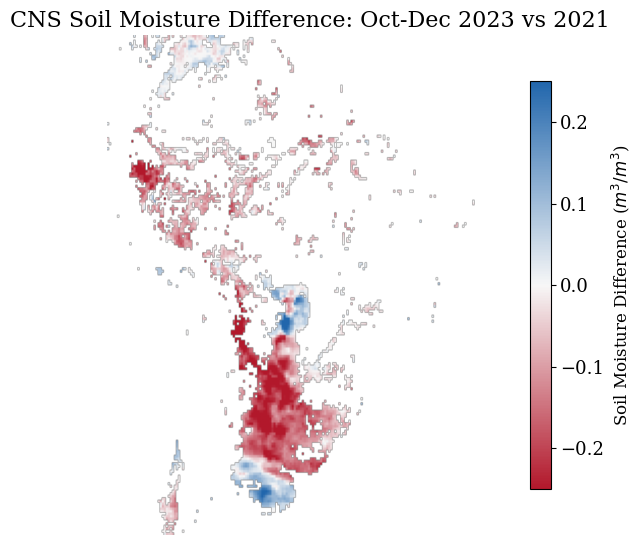

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# 加载数据
soil_ds = xr.open_dataset('/content/drive/My Drive/Science/processed_soil_moisture_2000-2024.nc')
mask_ds = xr.open_dataset('/content/drive/My Drive/Science/class_3.nc')

# 计算时间索引
start_idx1 = (2019 - 2000) * 12 + 9  # 2024年2月索引=284
start_idx2 = (2018 - 2000) * 12 + 9  # 2024年2月索引=284

# 提取数据并应用掩膜
mask = mask_ds['class'].where(mask_ds['class'] == 1)  # 假设1是目标掩膜值
soil_start1 = soil_ds['soil_moisture'].isel(time=start_idx1).where(mask.notnull())
soil_end1 = soil_ds['soil_moisture'].isel(time=start_idx1+3).where(mask.notnull())

soil_start2 = soil_ds['soil_moisture'].isel(time=start_idx2).where(mask.notnull())
soil_end2 = soil_ds['soil_moisture'].isel(time=start_idx2+3).where(mask.notnull())

# 计算差值
soil_diff1 = soil_end1 - soil_start1
soil_diff2 = soil_end2 - soil_start2

soil_diff = soil_diff1 - soil_diff2

#区域限制
region_diff = soil_diff.isel(x=slice(700, 900), y=slice(300, 400))

# 创建自定义色带：蓝色表示正值（湿润增加），红色表示负值（湿润减少）
colors = ["#b2182b", "#f7f7f7", "#2166ac"]  # 红 -> 白 -> 蓝
cmap_custom = LinearSegmentedColormap.from_list("custom_blue_red", colors)

# 创建可视化
plt.figure(figsize=(5.64, 5.64)) #8.46

# 绘制差值热力图
im = plt.imshow(region_diff,
                cmap=cmap_custom,
                vmin=-0.25,
                vmax=0.25,  # 根据实际数据范围调整
                aspect='auto'
                )

# 添加色标
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label('Soil Moisture Difference ($m^3/m^3$)', fontsize=12)

# 设置标题和坐标轴
plt.title('CNS Soil Moisture Difference: Oct-Dec 2023 vs 2021', fontsize=16)
plt.axis('off')  # 完全关闭坐标轴显示
# 添加网格线
plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


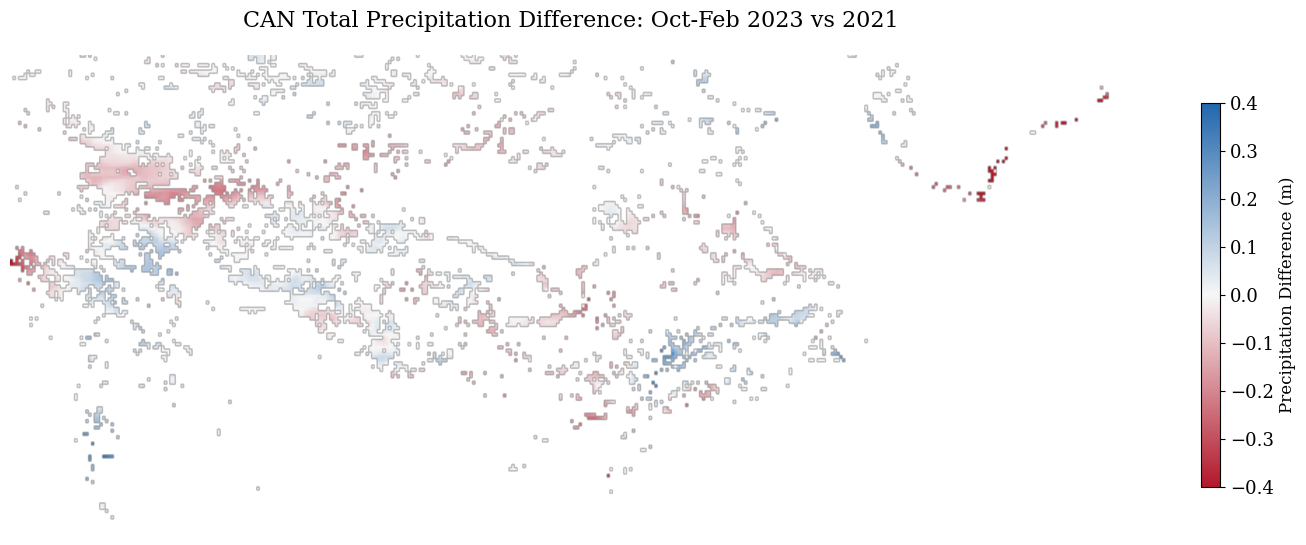

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 加载降水数据和掩膜
precip_ds = xr.open_dataset('/content/drive/My Drive/Science/P_2000-2024_monthly.nc')  # 替换为降水文件名
mask_ds = xr.open_dataset('/content/drive/My Drive/Science/class_5.nc')                      # 掩膜文件

# 计算时间索引
start_idx1 = (2023 - 2000) * 12 + 9  # 2024年2月索引=284
start_idx2 = (2021 - 2000) * 12 + 9  # 2024年2月索引=284

# 提取2023年9-12月降水数据
precip_subset1 = precip_ds['P'].isel(time=slice(start_idx1, start_idx1+5))
precip_subset2 = precip_ds['P'].isel(time=slice(start_idx2, start_idx2+5))

# 应用掩膜 (假设1是目标掩膜值)
mask = mask_ds['class'].where(mask_ds['class'] == 1)
masked_precip1 = precip_subset1.where(mask.notnull())
masked_precip2 = precip_subset2.where(mask.notnull())

# 计算区域降水总和
total_precip1 = masked_precip1.sum(dim='time', skipna=True)
total_precip2 = masked_precip2.sum(dim='time', skipna=True)

total_precip = (total_precip1 - total_precip2).where(mask.notnull())

# 应用区域限制 (300 < x < 600, 300 < y < 400)
region_precip = total_precip.isel(x=slice(200, 600), y=slice(50, 200))

colors = ["#b2182b", "#f7f7f7", "#2166ac"]  # 红 -> 白 -> 蓝
cmap_custom = LinearSegmentedColormap.from_list("custom_blue_red", colors)

# 创建可视化
plt.figure(figsize=(14.4, 5.64))

# 绘制降水总和热力图
im = plt.imshow(region_precip,
                cmap=cmap_custom,  # 使用蓝色系表示降水
                vmin=-0.4,
                vmax=0.4,  # 根据实际数据范围调整
                aspect='auto')

# 添加色标
cbar = plt.colorbar(im, shrink=0.8)
cbar.set_label('Precipitation Difference (m)', fontsize=12)

# 设置标题
plt.title('CAN Total Precipitation Difference: Oct-Feb 2023 vs 2021', fontsize=16, pad=20)

# 完全移除坐标轴
plt.axis('off')

plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


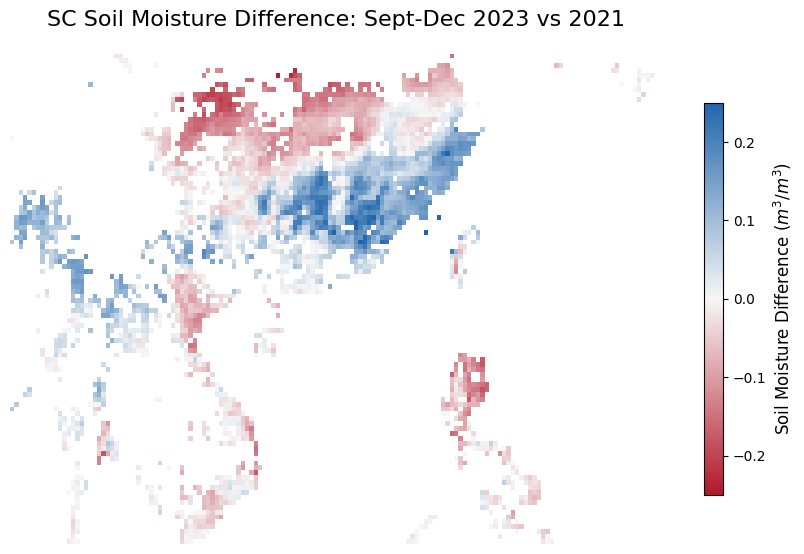

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 加载降水数据和掩膜
precip_ds = xr.open_dataset('/content/drive/My Drive/Science/dmv_2000-2024_monthly.nc')  # 替换为降水文件名
mask_ds = xr.open_dataset('/content/drive/My Drive/Science/class_3.nc')                      # 掩膜文件

# 计算时间索引
start_idx1 = (2023 - 2000) * 12 + 9  # 2024年2月索引=284
start_idx2 = (2022 - 2000) * 12 + 9  # 2024年2月索引=284

# 提取2023年9-12月降水数据
precip_subset1 = precip_ds['dmv'].isel(time=slice(start_idx1, start_idx1+3))
precip_subset2 = precip_ds['dmv'].isel(time=slice(start_idx2, start_idx2+3))

# 应用掩膜 (假设1是目标掩膜值)
mask = mask_ds['class'].where(mask_ds['class'] == 1)
masked_precip1 = precip_subset1.where(mask.notnull())
masked_precip2 = precip_subset2.where(mask.notnull())

# 计算区域降水总和
total_precip1 = masked_precip1.sum(dim='time', skipna=True)
total_precip2 = masked_precip2.sum(dim='time', skipna=True)

total_precip = (total_precip1 - total_precip2).where(mask.notnull())

# 应用区域限制 (200 < x < 600, 50 < y < 250)
region_precip = total_precip.isel(x=slice(700, 1200), y=slice(50, 200))

colors = ["#b2182b", "#f7f7f7", "#2166ac"]  # 红 -> 白 -> 蓝
cmap_custom = LinearSegmentedColormap.from_list("custom_blue_red", colors)

# 创建可视化
plt.figure(figsize=(14.4, 5.64))

# 绘制降水总和热力图
im = plt.imshow(region_precip,
                cmap=cmap_custom,  # 使用蓝色系表示降水
                vmin=-0.25,
                vmax=0.25,  # 根据实际数据范围调整
                aspect='auto')

# 添加色标
cbar = plt.colorbar(im, shrink=0.8)
cbar.set_label('Soil Moisture Difference ($m^3/m^3$)', fontsize=12)

# 设置标题
plt.title('SC Soil Moisture Difference: Sept-Dec 2023 vs 2021', fontsize=16, pad=20)

# 完全移除坐标轴
plt.axis('off')

plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


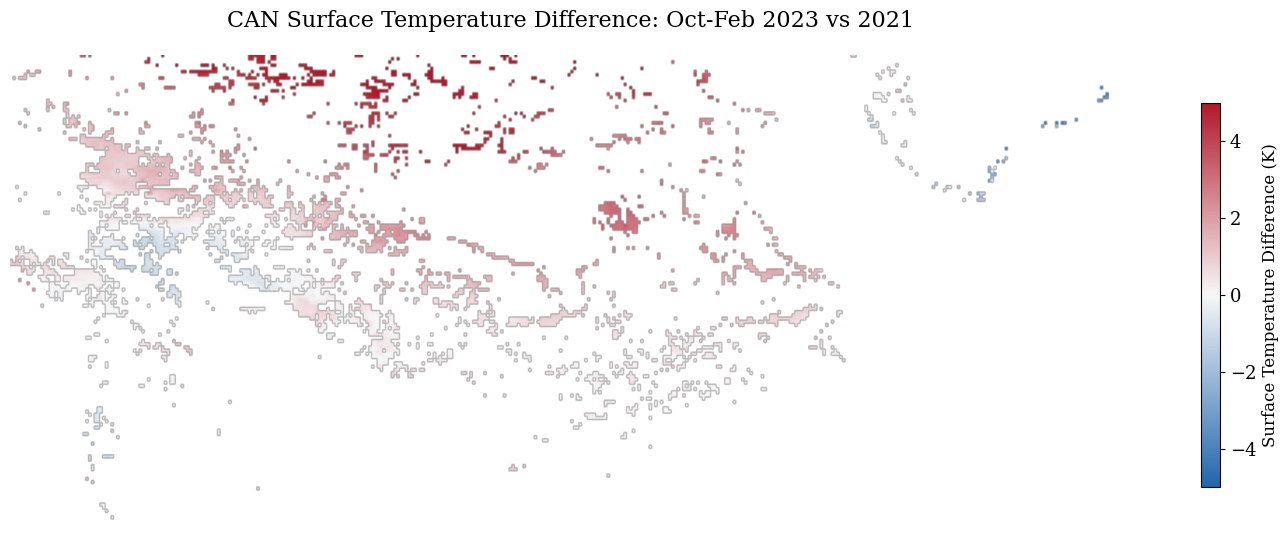

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 加载降水数据和掩膜
precip_ds = xr.open_dataset('/content/drive/My Drive/Science/Ts_2000-2024_monthly.nc')  # Ta
mask_ds = xr.open_dataset('/content/drive/My Drive/Science/class_5.nc')           # 掩膜文件

# 计算时间索引
start_idx1 = (2023 - 2000) * 12 + 9  # 2024年2月索引
start_idx2 = (2021 - 2000) * 12 + 9  # 2024年2月索引

# 提取2023年9-12月降水数据
precip_subset1 = precip_ds['Ts'].isel(time=slice(start_idx1, start_idx1+5))
precip_subset2 = precip_ds['Ts'].isel(time=slice(start_idx2, start_idx2+5))

# 应用掩膜 (假设1是目标掩膜值)
mask = mask_ds['class'].where(mask_ds['class'] == 1)
masked_precip1 = precip_subset1.where(mask.notnull())
masked_precip2 = precip_subset2.where(mask.notnull())

# 计算区域降水总和
total_precip1 = masked_precip1.mean(dim='time', skipna=True)
total_precip2 = masked_precip2.mean(dim='time', skipna=True)

total_precip = (total_precip1 - total_precip2).where(mask.notnull())

# 应用区域限制 (200 < x < 600, 50 < y < 250)
region_precip = total_precip.isel(x=slice(200, 600), y=slice(50, 200))

colors = ["#2166ac", "#f7f7f7", "#b2182b"]  # 红 -> 白 -> 蓝
cmap_custom = LinearSegmentedColormap.from_list("custom_blue_red", colors)

# 创建可视化
plt.figure(figsize=(14.4, 5.64))

# 绘制降水总和热力图
im = plt.imshow(region_precip,
                cmap=cmap_custom,  # 使用蓝色系表示降水
                vmin=-5,
                vmax=5,  # 根据实际数据范围调整 -4 4
                aspect='auto')

# 添加色标
cbar = plt.colorbar(im, shrink=0.8)
cbar.set_label('Surface Temperature Difference (K)', fontsize=12)

# 设置标题
plt.title('CAN Surface Temperature Difference: Oct-Feb 2023 vs 2021', fontsize=16, pad=20)
#Air Temperature

# 完全移除坐标轴
plt.axis('off')

plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


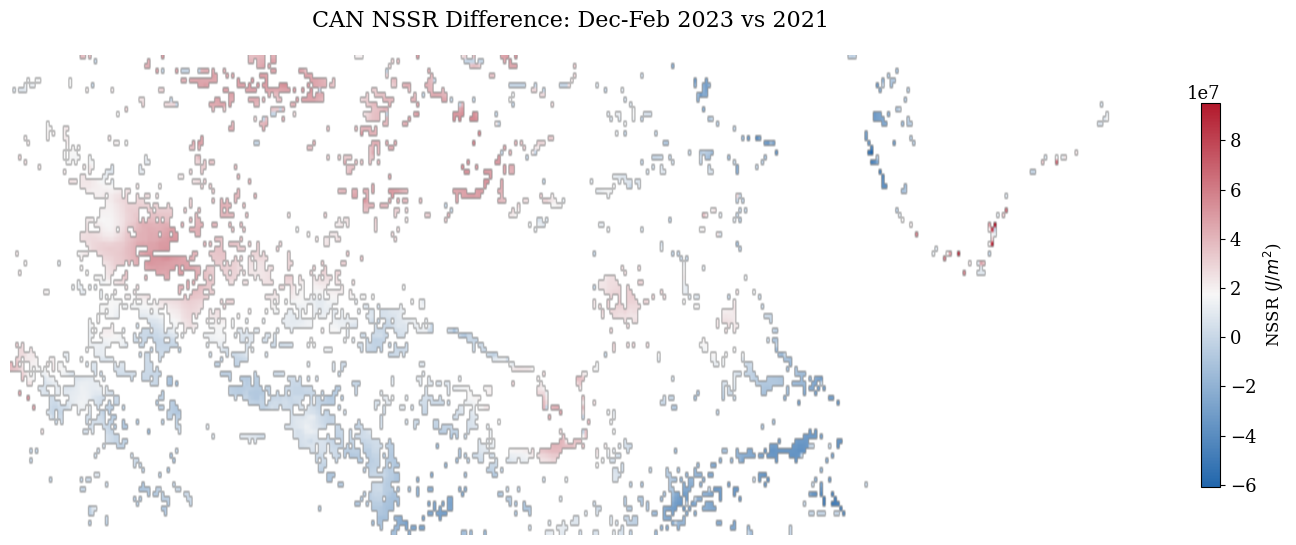

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 加载降水数据和掩膜
precip_ds = xr.open_dataset('/content/drive/My Drive/Science/NSSR_2000-2024_monthly.nc')  # 替换为降水文件名
mask_ds = xr.open_dataset('/content/drive/My Drive/Science/class_5.nc')                      # 掩膜文件

# 计算时间索引
start_idx1 = (2023 - 2000) * 12 + 9  # 2024年2月索引=284
start_idx2 = (2021 - 2000) * 12 + 9  # 2024年2月索引=284

# 提取2023年9-12月降水数据
precip_subset1 = precip_ds['NSSR'].isel(time=slice(start_idx1, start_idx1+5))
precip_subset2 = precip_ds['NSSR'].isel(time=slice(start_idx2, start_idx2+5))

# 应用掩膜 (假设1是目标掩膜值)
mask = mask_ds['class'].where(mask_ds['class'] == 1)
masked_precip1 = precip_subset1.where(mask.notnull())
masked_precip2 = precip_subset2.where(mask.notnull())

# 计算区域降水总和
total_precip1 = masked_precip1.mean(dim='time', skipna=True)
total_precip2 = masked_precip2.mean(dim='time', skipna=True)

total_precip = (total_precip1 - total_precip2).where(mask.notnull())

# 应用区域限制 (200 < x < 600, 50 < y < 250)
region_precip = total_precip.isel(x=slice(200, 600), y=slice(50, 150))

colors = ["#2166ac", "#f7f7f7", "#b2182b"]  # 红 -> 白 -> 蓝
cmap_custom = LinearSegmentedColormap.from_list("custom_blue_red", colors)

# 创建可视化
plt.figure(figsize=(14.4, 5.64))

# 绘制降水总和热力图
im = plt.imshow(region_precip,
                cmap=cmap_custom,  # 使用蓝色系表示降水
                aspect='auto')

# 添加色标
cbar = plt.colorbar(im, shrink=0.8)
cbar.set_label('NSSR ($J/m^2$)', fontsize=12)

# 设置标题
plt.title('CAN NSSR Difference: Dec-Feb 2023 vs 2021', fontsize=16, pad=20)

# 完全移除坐标轴
plt.axis('off')

plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


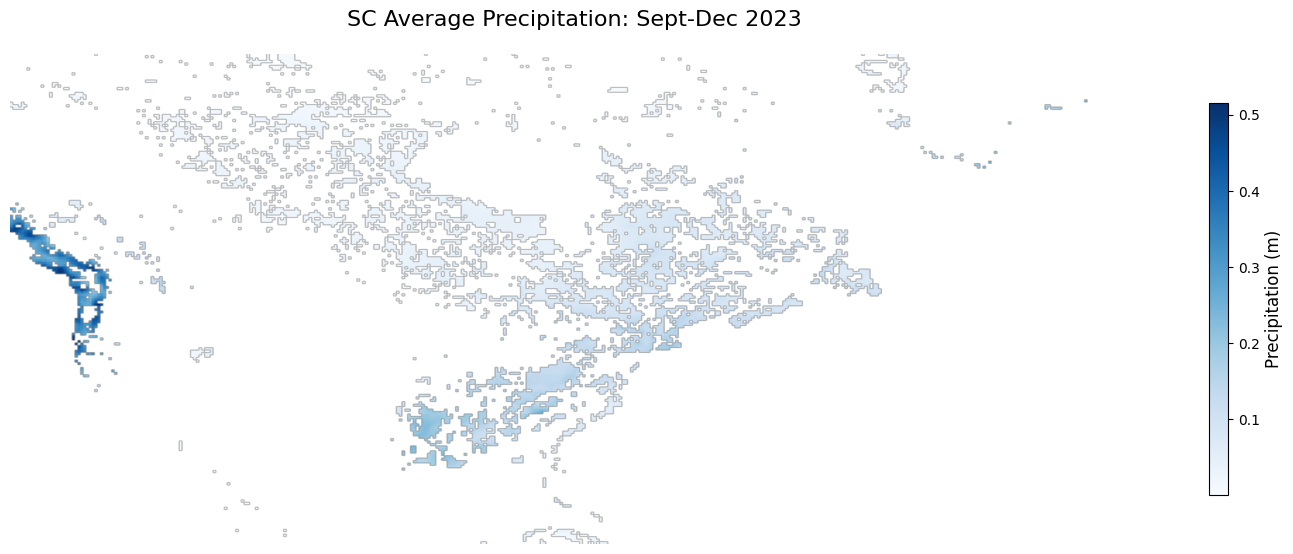

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 加载降水数据和掩膜
precip_ds = xr.open_dataset('/content/drive/My Drive/Science/P_2000-2024_monthly.nc')  # 替换为降水文件名
mask_ds = xr.open_dataset('/content/drive/My Drive/Science/class_3.nc')                      # 掩膜文件

# 计算时间索引
start_idx = (2024 - 2000) * 12 + 2  # 2024年2月索引=284

# 提取2023年9-12月降水数据
precip_subset = precip_ds['P'].isel(time=slice(start_idx, start_idx+2))

# 应用掩膜 (假设1是目标掩膜值)
mask = mask_ds['class'].where(mask_ds['class'] == 1)
masked_precip = precip_subset.where(mask.notnull())

# 计算区域降水总和
total_precip = masked_precip.mean(dim='time', skipna=True)

# 应用区域限制 (200 < x < 600, 50 < y < 250)
region_precip = total_precip.isel(x=slice(200, 600), y=slice(50, 250))

# 创建可视化
plt.figure(figsize=(14.4, 5.64))

colors = ["#2166ac", "#f7f7f7", "#b2182b"]  # 红 -> 白 -> 蓝
cmap_custom = LinearSegmentedColormap.from_list("custom_blue_red", colors)

# 绘制降水总和热力图
im = plt.imshow(region_precip,
                cmap='Blues',  # 使用蓝色系表示降水
                aspect='auto')

# 添加色标
cbar = plt.colorbar(im, shrink=0.8)
cbar.set_label('Precipitation (m)', fontsize=12)

# 设置标题
plt.title('SC Average Precipitation: Sept-Dec 2023', fontsize=16, pad=20)

# 完全移除坐标轴
plt.axis('off')

plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


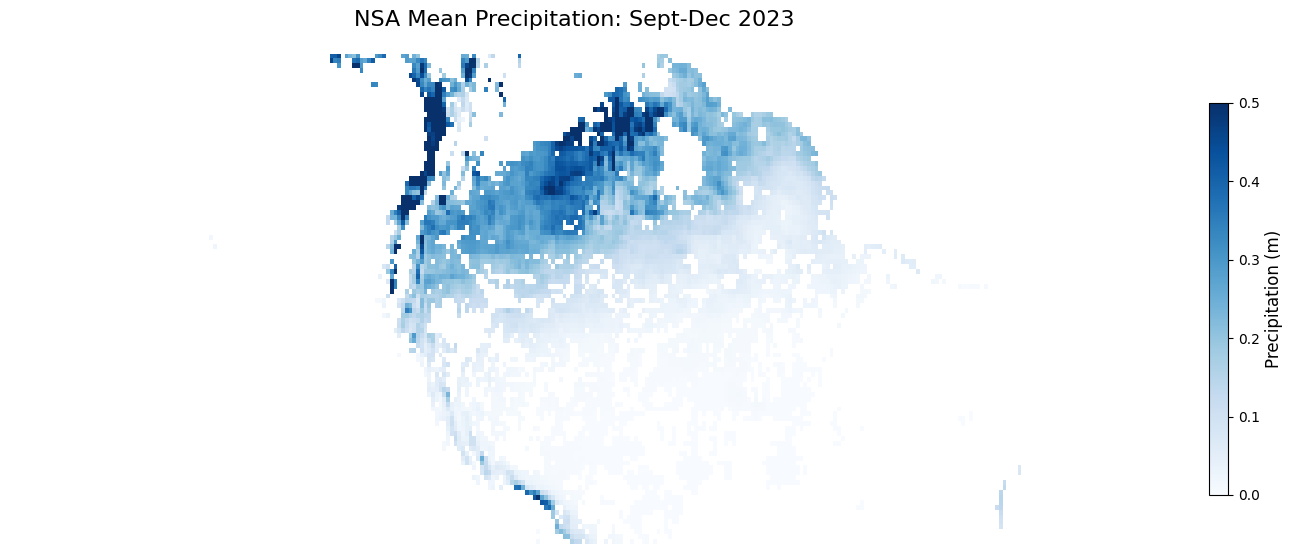

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# 加载降水数据和掩膜
precip_ds = xr.open_dataset('/content/drive/My Drive/Science/P_2000-2024_monthly.nc')  # 替换为降水文件名
mask_ds = xr.open_dataset('/content/drive/My Drive/Science/class_3.nc')                      # 掩膜文件

# 计算时间索引
start_idx = (2023 - 2000) * 12 + 9  # 2024年2月索引=284

# 提取2023年9-12月降水数据
precip_subset = precip_ds['P'].isel(time=slice(start_idx, start_idx+1))

# 应用掩膜 (假设1是目标掩膜值)
mask = mask_ds['class'].where(mask_ds['class'] == 1)
masked_precip = precip_subset.where(mask.notnull())

# 计算区域降水总和
total_precip = masked_precip.mean(dim='time', skipna=True)

# 应用区域限制 (200 < x < 600, 50 < y < 250)
region_precip = total_precip.isel(x=slice(300, 600), y=slice(300, 400))

# 创建可视化
plt.figure(figsize=(14.4, 5.64))

# 绘制降水总和热力图
im = plt.imshow(region_precip,
                cmap='Blues',  # 使用蓝色系表示降水
                vmin=0,
                vmax=0.50,  # 根据实际数据范围调整
                aspect='auto')

# 添加色标
cbar = plt.colorbar(im, shrink=0.8)
cbar.set_label('Precipitation (m)', fontsize=12)

# 设置标题
plt.title('NSA Mean Precipitation: Sept-Dec 2023', fontsize=16, pad=20)

# 完全移除坐标轴
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#!pip install cftime

from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import cftime  # 必须导入

# 加载降水数据和掩膜
ds = xr.open_dataset('/content/drive/My Drive/Science/CMIP6/MPI-ESM1-2-LR_201501-203412.nc')  #IPSL-CM6A-LR

# 2. 用户自定义经纬度范围 (示例值)
min_lon = 61.0   # 最小经度 (0-360°)
max_lon = 88.0   # 最大经度
min_lat = 56.0    # 最小纬度 (-89.46-89.46°)
max_lat = 66.0    # 最大纬度

# 3. 提取指定区域数据
soil_moisture = ds["mrsos"].sel(
    lon=slice(min_lon, max_lon),
    lat=slice(min_lat, max_lat)
)/100


# 4. 筛选2021-2024年数据
start_date = "2021-01-01"
end_date = "2024-12-31"
sm_subset = soil_moisture.sel(time=slice(start_date, end_date))

# 5. 计算月平均值 (全球平均)
# 先计算空间平均 (经度+纬度维度平均)
global_mean = sm_subset.mean(dim=["lon", "lat"])

# 再计算月平均
monthly_mean = global_mean.resample(time="1ME").mean()

## 6. 绘制曲线图
#fig, ax = plt.subplots(figsize=(14, 7))
#
# 绘制月均土壤湿度曲线
#plt.plot(monthly_mean.time, monthly_mean,
#         color="royalblue",
#         linewidth=2,
#         marker="o",
#         markersize=5)
#
## 设置图表格式
#plt.title("Monthly Mean Surface Soil Moisture (2021-2024)", fontsize=14)
#plt.xlabel("Time", fontsize=12)
#plt.ylabel("Soil Moisture (mrsos)", fontsize=12)
#
## 解决x轴拥挤问题 - 智能显示标签
#ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # 每3个月显示一个主刻度
#ax.xaxis.set_minor_locator(mdates.MonthLocator())  # 每月一个次刻度
#ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))  # 格式: 月份缩写+年份
#
## 设置y轴
#ax.yaxis.set_major_locator(MaxNLocator(10))  # 智能选择刻度数量

## 添加年月标签
#date_labels = [t.strftime("%Y-%m") for t in pd.to_datetime(monthly_mean.time.values)]

#plt.tight_layout()
#plt.show()

# 7. 输出统计信息
print("=== 数据统计 ===")
for value in monthly_mean.values:
    print(value)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== 数据统计 ===
0.33284270763397217
0.32915595173835754
0.3281833231449127
0.34653955698013306
0.36051231622695923
0.33467498421669006
0.3328200876712799
0.30565550923347473
0.332489550113678
0.34971606731414795
0.3367069661617279
0.3369368612766266
0.329389363527298
0.3261030614376068
0.32403603196144104
0.34156179428100586
0.3625410199165344
0.3252902925014496
0.306244432926178
0.3280327320098877
0.3559039235115051
0.3567467927932739
0.35365936160087585
0.33902469277381897
0.3341967463493347
0.3314707279205322
0.32895156741142273
0.3404165208339691
0.3648025393486023
0.33355146646499634
0.33256879448890686
0.3378039002418518
0.3655807077884674
0.36947470903396606
0.3656933903694153
0.3461199998855591
0.3388892412185669
0.3356928825378418
0.3461012542247772
0.3574153482913971
0.36850255727767944
0.3510737121105194
0.32533448934555054
0.3268306851387024
0.348965

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
读取NetCDF文件...


/tmp/ipykernel_1602/3887365463.py:32: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(file_paths, combine='by_coords')


提取区域数据...


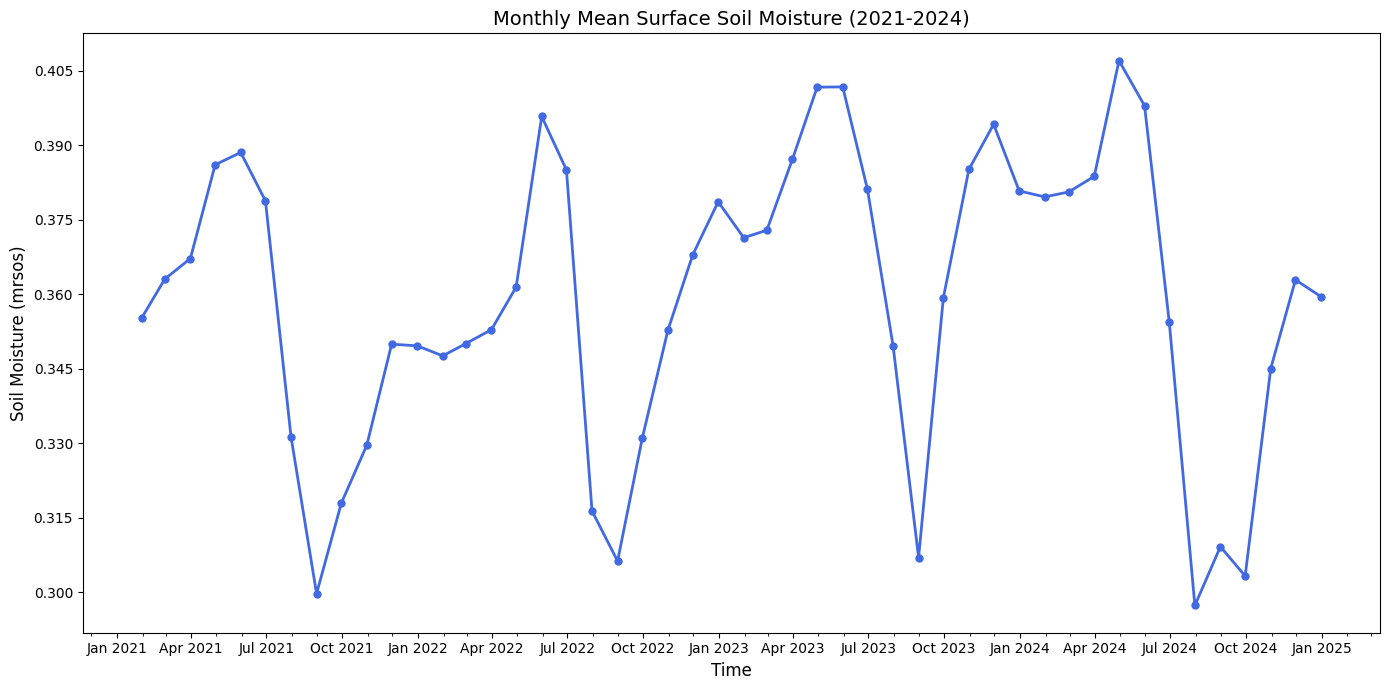

0.35523245
0.36305493
0.36718622
0.38606435
0.3885459
0.37880722
0.33128816
0.2996924
0.31791288
0.3296439
0.34993678
0.3496053
0.34758264
0.35005027
0.35285297
0.3614323
0.39579746
0.38502464
0.31633702
0.3062554
0.33103558
0.35273704
0.36787122
0.37861562
0.37137023
0.37288848
0.38717148
0.40170076
0.4017482
0.3811125
0.3496668
0.30695117
0.3592446
0.385127
0.3942254
0.3807982
0.37959364
0.38058832
0.38372365
0.40704897
0.39794844
0.3543197
0.29730886
0.30915675
0.30324185
0.34502566
0.36289537
0.35949427


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
from datetime import datetime
from matplotlib.ticker import MaxNLocator

# 1. 设置参数（请根据你的需求修改这些值）
# =============================================
min_lon = 61.0   # 最小经度 (0-360°)
max_lon = 88.0   # 最大经度
min_lat = 56.0    # 最小纬度 (-89.46-89.46°)
max_lat = 66.0    # 最大纬度
output_csv = "soil_moisture_timeseries.csv"  # CSV输出文件名
output_plot = "soil_moisture_plot.png"       # 图表输出文件名

# 2. 读取并合并NetCDF文件
# =============================================
print("读取NetCDF文件...")  #EC-Earth3  EC-Earth3-Veg  EC-Earth3-Veg-LR  EC-Earth3-CC
file_paths = [
    "/content/drive/My Drive/Science/CMIP6/EC-Earth3-CC_202101-202112.nc",
    "/content/drive/My Drive/Science/CMIP6/EC-Earth3-CC_202201-202212.nc",
    "/content/drive/My Drive/Science/CMIP6/EC-Earth3-CC_202301-202312.nc",
    "/content/drive/My Drive/Science/CMIP6/EC-Earth3-CC_202401-202412.nc"
]

# 使用xarray打开所有文件
ds = xr.open_mfdataset(file_paths, combine='by_coords')

# 3. 提取指定区域的数据
# =============================================
print("提取区域数据...")
# 选择经纬度范围
area_data = ds['mrsos'].sel(
    lon=slice(min_lon, max_lon),
    lat=slice(min_lat, max_lat)
)/100

# 4. 筛选2021-2024年数据
start_date = "2021-01-01"
end_date = "2024-12-31"
sm_subset = area_data.sel(time=slice(start_date, end_date))

# 计算区域月均值（空间平均）
monthly_avg = sm_subset.mean(dim=['lat', 'lon'])

# 再计算月平均
monthly_mean = monthly_avg.resample(time="1ME").mean()

# 6. 绘制曲线图
fig, ax = plt.subplots(figsize=(14, 7))

# 绘制月均土壤湿度曲线
plt.plot(monthly_mean.time, monthly_mean,
         color="royalblue",
         linewidth=2,
         marker="o",
         markersize=5)

# 设置图表格式
plt.title("Monthly Mean Surface Soil Moisture (2021-2024)", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Soil Moisture (mrsos)", fontsize=12)

# 解决x轴拥挤问题 - 智能显示标签
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # 每3个月显示一个主刻度
ax.xaxis.set_minor_locator(mdates.MonthLocator())  # 每月一个次刻度
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))  # 格式: 月份缩写+年份

# 设置y轴
ax.yaxis.set_major_locator(MaxNLocator(10))  # 智能选择刻度数量

# 添加年月标签
date_labels = [t.strftime("%Y-%m") for t in pd.to_datetime(monthly_mean.time.values)]

plt.tight_layout()
plt.show()
for value in monthly_mean.values:
    print(value)